# **Desarrollo de Actividad 3:  De los datos a las decisiones: clasificación y evaluación de modelos**

**Proyecto:** Aplicación de modelos predictivo en el analisis de adicción al smartphone.

**Presentado por:**

•	Adriana Patricia Rodriguez Toloza

**Fecha:** 1 de junio de 2026

## **Selección y descripción de la base de datos:**

La base de datos seleccionada se llama "Smartphone usage addiction analysis", disponible en la plataforma kaggle, y contiene información acerca de los patrones de uso de smartphones e indicadores del nivel de adicción de 7500 individuos. El dataset contiene las siguientes variables:


*   **Transaction_id:** Identificador de la transacción
*   **User_id:** Identificador del usuario
*   **Age:** Edad
*   **Gender:** Género
*   **Daily_screen_time_hours:** Horas diarias de uso del smartphone
*   **Social_media_hours:** Tiempo en horas en redes sociales
*   **Gaming_hours:** Tiempo en horas en videojuegos
*   **Work_study_hours:** Horas de trabajo o estudio
*   **Sleep_hours:** Horas de sueño
*   **Nottificatios_per_day:** Número de notitficaciones por día
*   **App_opens_per_day:** Número de veces que abre aplicaciones al día
*   **Weekend_screen_time:** Tiempo en pantalla en fines de semana
*   **Stress_level:** Nivel de estrés
*   **Academic_work_impact:** Impacto sobre el rendimiento académico o laboral
*   **Addiction_level:** Nivel de adicción
*   **Addicted_label:** Etiqueta del nivel de adicción (Variable Binaria donde 0 es baja, 1 es media o severa)

Para esta base de datos, las variables Transaction_id e User_id son equivalentes y cumplen la función de identificar registros.


## **Contexto y análisis del problema:**

Desde el desarrollo de las diferentes funciones de los smartphones ha generado importantes beneficios en términos de rapidez y conectividad, sin embargo, también ha propiciado una creciente dependencia a estos dispositivos.

 La Organización Mundial de la Salud (2018) ha manifestado su preocupación sobre las implicaciones del uso excesivo de dispositivos electrónicos a la salud pública. Entre las principales consecuencias se destacan la baja autoestima, los cambios de humor, los trastornos del sueño como el insomnio, así como molestias físicas como dolor y rigidez en el cuello, sequedad ocular, síndrome de visión por ordenador y debilidad en el pulgar, entre otras (National Library of Medicine, 2016).

Asimismo, se han identificado nuevos trastornos y comportamientos asociados, como la “textiedad” (ansiedad por no recibir o enviar mensajes de texto), el síndrome de vibración o zumbido fantasma (percepción ilusoria de que el teléfono suena o vibra) y la conducta conocida como communifaking, en la cual el individuo simula estar ocupado en interacciones digitales para evitar conversaciones presenciales, buscar aceptación social o proyectar una determinada imagen.

En este contexto, se abordará el análisis de una base de datos compuesta por 7.500 personas, con el fin de identificar patrones de comportamiento y desarrollar modelos que permitan detectar y predecir niveles de adicción a dispositivos móviles. Esto contribuirá al diseño de estrategias de prevención e intervención orientadas a mitigar los impactos negativos en la salud mental.


## **Selección de variable predictoria:**


La variable binaria de predicción será el **índice de adicción.**

## **Paso 1: Cargue de información:**

### ***1.1 Importar librerias***

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import time

from sklearn.metrics import  ConfusionMatrixDisplay, precision_recall_curve,confusion_matrix,brier_score_loss, roc_auc_score, roc_curve, accuracy_score, precision_score, recall_score,f1_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.calibration import calibration_curve
from sklearn.tree import plot_tree,export_text
from sklearn.metrics import precision_recall_fscore_support
from sklearn.model_selection import train_test_split, GridSearchCV,StratifiedKFold
from scipy.stats import skew, kurtosis, kurtosistest, pearsonr
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.inspection import permutation_importance


### ***1.2 Conectar al drive:***

---



In [ ]:
from google.colab import drive #Importo el módulo drive del paquete google.colab
drive.mount("/content/drive") #Monto mi drive en la ruta especificada

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### ***1.3 Lectura de la base de datos:***


In [ ]:
df=pd.read_csv("/content/drive/MyDrive/Colab_Notebooks/Supervisados/Smartphone_Usage_And_Addiction_Analysis_7500_Rows.csv") #Utilizo pandas para leer la base de datos
df.head() #Visualización de las primeras filas

,transaction_id,user_id,age,gender,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,addiction_level,addicted_label
0,TXN00001,U00001,21,Male,3.23,2.01,0.89,4.55,7.55,248,154,3.95,Medium,Yes,NaN,0
1,TXN00002,U00002,24,Other,5.09,3.81,2.24,4.44,7.66,127,71,6.71,Medium,Yes,NaN,0
2,TXN00003,U00003,31,Other,6.06,1.36,3.83,2.35,4.92,44,106,8.68,High,No,Mild,0
3,TXN00004,U00004,32,Other,7.83,5.85,1.51,3.54,8.23,178,107,9.77,High,Yes,Moderate,1
4,TXN00005,U00005,25,Male,9.96,5.92,3.42,5.27,6.21,136,177,12.55,Low,No,Severe,1


## **Paso 2: Exploración inicial de los datos:**

### ***2.1 Exploración e identificación del tipo de variables:***

In [ ]:
df.columns

Index(['transaction_id', 'user_id', 'age', 'gender', 'daily_screen_time_hours',
       'social_media_hours', 'gaming_hours', 'work_study_hours', 'sleep_hours',
       'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time',
       'stress_level', 'academic_work_impact', 'addiction_level',
       'addicted_label'],
      dtype='object')

In [ ]:
#Renombre de las variables
df.rename(columns={
          'transaction_id':"ID Transacción",
          'user_id':"ID Usuario",
          'age':"Edad",
          'gender':"Género",
          'daily_screen_time_hours':"Tiempo de uso diario del smartphone (Horas)" ,
          "social_media_hours": "Tiempo de uso de redes sociales (Horas)",
          'gaming_hours':"Tiempo usado en videojuegos (Horas)",
          'work_study_hours':"Tiempo destinado a trabajo o estudio (Horas)",
          'sleep_hours':"Horas de sueño",
          'notifications_per_day':"Número de notificaciones por día",
          'app_opens_per_day':"Número de veces que abre aplicaciones al día",
          'weekend_screen_time':"Tiempo en pantalla los fines de semana",
          'stress_level':"Nivel de estrés",
          'academic_work_impact':"Impacto sobre el rendimiento académico o laboral",
          'addiction_level':"Nivel de adicción",
          'addicted_label':"Indice de adicción"},
          inplace=True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7500 entries, 0 to 7499
Data columns (total 16 columns):
 #   Column                                            Non-Null Count  Dtype  
---  ------                                            --------------  -----  
 0   ID Transacción                                    7500 non-null   object 
 1   ID Usuario                                        7500 non-null   object 
 2   Edad                                              7500 non-null   int64  
 3   Género                                            7500 non-null   object 
 4   Tiempo de uso diario del smartphone (Horas)       7500 non-null   float64
 5   Tiempo de uso de redes sociales (Horas)           7500 non-null   float64
 6   Tiempo usado en videojuegos (Horas)               7500 non-null   float64
 7   Tiempo destinado a trabajo o estudio (Horas)      7500 non-null   float64
 8   Horas de sueño                                    7500 non-null   float64
 9   Número de notificac

Con el método .info() es posible identificar que la base de datos está compuesto por 7500 registros y 16 columnas. De esas 16 columnas tenemos:
* 6 variables del tipo texto (categórica):
  * Identificador de la transacción (Ordinal)
  * Identificador del usuario (Ordinal)
  * Género (Nominal)
  * Nivel de estrés (Ordinal)
  * Impacto sobre el rendimiento académico o laboral (Nominal)
  * Nivel de adicción (Ordinal)
* 6 variables numéricas del tipo continua:
  * Tiempo de uso diario del smartphone (Horas)
  * Tiempo de uso de redes sociales (Horas)
  * Tiempo usado en videojuegos (Horas)
  * Tiempo destinado a trabajo o estudio (Horas)
  * Horas de sueño
  * Tiempo en pantalla en fines de semana
* 4 variables numéricas discretas:
  * Edad
  * Número de notificaciones por día
  * Número de veces que abre aplicaciones al día
  * Indice de adicción

La variable binaria "Indice de adicción" es la variable dependiente (Y) a pronosticar.


**Valores nulos:** Mediante el método .info() es posible identificar que la variable "Nivel de adicción" presenta 6681 valores no nulos, es decir, que de los 7500 registros cerca de 819 son nulos en esta variable.

### ***2.2 Listas de variables categóricas y numéricas:***

Con el fin de facilitar la ejecución de pasos aplicados, se realizará la diferenciación de variables categóricas y numéricas a analizar:

In [ ]:
df.columns

Index(['ID Transacción', 'ID Usuario', 'Edad', 'Género',
       'Tiempo de uso diario del smartphone (Horas)',
       'Tiempo de uso de redes sociales (Horas)',
       'Tiempo usado en videojuegos (Horas)',
       'Tiempo destinado a trabajo o estudio (Horas)', 'Horas de sueño',
       'Número de notificaciones por día',
       'Número de veces que abre aplicaciones al día',
       'Tiempo en pantalla los fines de semana', 'Nivel de estrés',
       'Impacto sobre el rendimiento académico o laboral', 'Nivel de adicción',
       'Indice de adicción'],
      dtype='object')

> Es importante tener en cuenta que la variable "Indice de adicción" es una variable binaria (0 y 1) en la cual representa el nivel de adicción. Por lo cual, se puede utilizar para analizar su información mediante gráficos de barras o porcentuales en lugar de histogramas.}

In [ ]:
#Dentro de las variables categoricas se eliminan las variables de tipo identificatoria (ID)
variables_categoricas=df.select_dtypes(exclude=[np.number]).columns.tolist()
variables_categoricas.remove("ID Transacción")
variables_categoricas.remove("ID Usuario")
print(variables_categoricas)

['Género', 'Nivel de estrés', 'Impacto sobre el rendimiento académico o laboral', 'Nivel de adicción']


In [ ]:
variables_numericas=df.select_dtypes(include=[np.number]).columns.tolist()
variables_numericas

['Edad',
 'Tiempo de uso diario del smartphone (Horas)',
 'Tiempo de uso de redes sociales (Horas)',
 'Tiempo usado en videojuegos (Horas)',
 'Tiempo destinado a trabajo o estudio (Horas)',
 'Horas de sueño',
 'Número de notificaciones por día',
 'Número de veces que abre aplicaciones al día',
 'Tiempo en pantalla los fines de semana',
 'Indice de adicción']

### ***2.3 Medidas de centralidad, localización, variabilidad y forma:***

In [ ]:
df.describe().round(2)

,Edad,Tiempo de uso diario del smartphone (Horas),Tiempo de uso de redes sociales (Horas),Tiempo usado en videojuegos (Horas),Tiempo destinado a trabajo o estudio (Horas),Horas de sueño,Número de notificaciones por día,Número de veces que abre aplicaciones al día,Tiempo en pantalla los fines de semana,Indice de adicción
count,7500.00,7500.00,7500.00,7500.00,7500.00,7500.00,7500.00,7500.00,7500.00,7500.00
mean,26.57,7.50,3.27,2.01,3.24,6.74,134.26,97.83,9.24,0.71
std,5.20,2.61,1.59,1.15,1.60,1.28,66.59,48.42,2.72,0.45
min,18.00,3.00,0.50,0.00,0.50,4.50,20.00,15.00,3.58,0.00
25%,22.00,5.22,1.91,1.02,1.85,5.63,76.00,55.00,6.96,0.00
50%,27.00,7.52,3.27,2.04,3.23,6.72,134.00,98.00,9.26,1.00
75%,31.00,9.81,4.63,2.99,4.64,7.84,191.00,140.00,11.54,1.00
max,35.00,12.00,6.00,4.00,6.00,9.00,250.00,180.00,14.88,1.00


In [ ]:
moda= df[variables_numericas].mode().T

In [ ]:
#Comparación media, mediana y moda de variables numéricas
media=df[variables_numericas].mean()
mediana=df[variables_numericas].median()
comparacion=pd.DataFrame({"Media":media,"Mediana":mediana,"Moda 1":moda[0], "Moda 2": moda[1]})
comparacion


,Media,Mediana,Moda 1,Moda 2
Edad,26.568800,27.000,31.00,NaN
Tiempo de uso diario del smartphone (Horas),7.499912,7.525,8.13,NaN
Tiempo de uso de redes sociales (Horas),3.273484,3.270,0.99,3.07
Tiempo usado en videojuegos (Horas),2.014183,2.040,2.37,NaN
Tiempo destinado a trabajo o estudio (Horas),3.242420,3.230,3.07,3.66
Horas de sueño,6.737561,6.720,7.77,NaN
Número de notificaciones por día,134.257333,134.000,184.00,NaN
Número de veces que abre aplicaciones al día,97.832400,98.000,109.00,NaN
Tiempo en pantalla los fines de semana,9.243827,9.260,11.92,NaN
Indice de adicción,0.707733,1.000,1.00,NaN


##### **Medidas de centralidad (Media, mediana y moda):**
* Al analizar la mediana y media de cada una de las variables (excepción: indice de adicción), se evidencia que son similares. Sin embargo,  es importante recordar que para hablar de simetria se cumple que la media, mediana y moda son la misma. Sin embargo, como podemos observar en la tabla de comparación se observa que la moda difiere de manera importante de la moda y mediana y por lo cual no se puede hablar de simetria en las variables  (como la que se presentaria en una distribución gausiana). Esto representa que los datos no tienden hacia un patrón único de comportamiento de los individuos o promedio, como se presenta en este tipo de distribución.
* La similitud entre la media y la mediana podria sugerir una posible baja cantidad o importancia de valores extremos o outliers que influyan en estas medidas de localización, permitiendo que sean similares.
* Vemos que la variables Tiempo de uso de redes sociales (Horas) y Tiempo destinado a trabajo o estudio (Horas)	son bimodales (tienen dos modas), mientras las demás variables son unimodales.
* Dada la presencia de valores promedio altos (Número de notificaciones por día) y bajos (Tiempo usado en videojuegos), muestra la necesidad de realizar escalamiento de las variables.

##### **Medidas de localización (Mínimo, Q1, Mediana, Q3, Máximo):**



Para complementar el análisis, se realizará el cálculo del rango entre cuartiles (Q1,Q2,Q3 y Q4) y del rango intercuartílico (Q3-Q1):

In [ ]:
# Rangos entre Q1,Q2,Q3 y Q4
df_rangos=df.copy()

rangos=[]
for col in variables_numericas:
  q1=df_rangos[col].quantile(0.25)
  q2=df_rangos[col].quantile(0.50)
  q3=df_rangos[col].quantile(0.75)
  q4=df_rangos[col].quantile(1)
  rangos.append({
      "Variable":col,
      "Rango Q2-Q1":q2-q1,
      "Rango Q3-Q2":q3-q2,
      "Rango Q4-Q3":q4-q3})
  rangos_df=pd.DataFrame(rangos)
rangos_df

,Variable,Rango Q2-Q1,Rango Q3-Q2,Rango Q4-Q3
0,Edad,5.000,4.000,4.00
1,Tiempo de uso diario del smartphone (Horas),2.305,2.285,2.19
2,Tiempo de uso de redes sociales (Horas),1.360,1.360,1.37
3,Tiempo usado en videojuegos (Horas),1.020,0.950,1.01
4,Tiempo destinado a trabajo o estudio (Horas),1.380,1.410,1.36
5,Horas de sueño,1.090,1.120,1.16
6,Número de notificaciones por día,58.000,57.000,59.00
7,Número de veces que abre aplicaciones al día,43.000,42.000,40.00
8,Tiempo en pantalla los fines de semana,2.300,2.280,3.34
9,Indice de adicción,1.000,0.000,0.00


In [ ]:
#Rango Intercuartilico (Q3-Q1)
for col in variables_numericas:
  q1=df[col].quantile(0.25)
  q2=df[col].quantile(0.50)
  q3=df[col].quantile(0.75)
  IQR=(q3-q1).round(2)
  print(f"IQR de la variable {col}:",IQR)

IQR de la variable Edad: 9.0
IQR de la variable Tiempo de uso diario del smartphone (Horas): 4.59
IQR de la variable Tiempo de uso de redes sociales (Horas): 2.72
IQR de la variable Tiempo usado en videojuegos (Horas): 1.97
IQR de la variable Tiempo destinado a trabajo o estudio (Horas): 2.79
IQR de la variable Horas de sueño: 2.21
IQR de la variable Número de notificaciones por día: 115.0
IQR de la variable Número de veces que abre aplicaciones al día: 85.0
IQR de la variable Tiempo en pantalla los fines de semana: 4.58
IQR de la variable Indice de adicción: 1.0


* Los valores mínimos de las variables numéricas son factibles. Por su parte, los valores máximos de Tiempo de uso diario del smartphones en horas, Número de notificaciones por día y Número de veces que abre aplicaciones al día muestran valores llamativos pero que podrian ser posibles a factores relacionados a patrones de adicción al teléfono.
* Al observar los valores máximos de las variables es posible identificar que existe predominancia en algunas como el número de notificaciones al día (250) mientras que valores como el tiempo usado en video juegos presentan valores máximos de menor tamaño (4). Esto confirma la necesidad de hacer escalamiento para poder comparar y analizar las variables.
* Al estudiar el rango entre cuartiles (Q1,Q2,Q3 y Q4) de cada variable se evidencia que trata de ser muy homogeneo y no se encuentran saltos significativos, mostrando estabilidad en la variable. Sin embargo, el rango entre cuartiles de las diferentes variables es muy distinto, especialmente en las variables Número de notificaciones por día y Número de veces que abre aplicaciones al día que mostraron una alta desviación estándar.
* El Rango intercuartilico IQR=(Q3-Q1) que muestra el 50% de datos central. Al encontrar un IQR tan alto en las variables Número de notificaciones por día y Número de veces que abre aplicaciones al día, refleja que existe una alta dispersión en los datos.

#####**Medidas de variabilidad (Varianza, desviación estándar y coeficiente de variación):**

In [ ]:
#Varianza y Desviación estandar
varianza=(df[variables_numericas].var()).round(2)
desviacion=(df[variables_numericas].std()).round(2)

#Coeficiente de variacion
Coeficiente_de_variacion=((df[variables_numericas].std()/df[variables_numericas].mean())*100).round(2)

In [ ]:
medidas_variabilidad=pd.DataFrame({"Varianza":varianza,"Desviación estándar":desviacion,"Coeficiente de variación":Coeficiente_de_variacion})
medidas_variabilidad

,Varianza,Desviación estándar,Coeficiente de variación
Edad,27.01,5.20,19.56
Tiempo de uso diario del smartphone (Horas),6.81,2.61,34.79
Tiempo de uso de redes sociales (Horas),2.51,1.59,48.43
Tiempo usado en videojuegos (Horas),1.31,1.15,56.90
Tiempo destinado a trabajo o estudio (Horas),2.56,1.60,49.37
Horas de sueño,1.65,1.28,19.05
Número de notificaciones por día,4433.81,66.59,49.60
Número de veces que abre aplicaciones al día,2344.82,48.42,49.50
Tiempo en pantalla los fines de semana,7.39,2.72,29.41
Indice de adicción,0.21,0.45,64.27


* En términos de varianza, se evidencia que las variables Número de notificaciones por día y Número de veces que abre aplicaciones al día presentan una variabilidad significativamente alta. Por lo cual son variables con una alta dispersión de sus datos con relación a la media y por lo tanto para ser analizadas por el modelo requiere que se estandarice.
* Las variables Tiempo usado en videojuegos y Horas de suelo presentan variabilidades significativamente bajas, sin embargo, en estudios investigativos si se consideran factores importantes relacionados a la adicción como a los teléfonos.
* El coeficiente de variación para las variables Tiempo usado en videojuegos (56.90%),  Número de notificaciones por día (49.60%), Número de veces que abre aplicaciones al día (49.50%), Tiempo destinado a trabajo o estudio (49.37%)y Tiempo de uso de redes sociales (48.43%)  muestra que existe una heterogeneidad de los datos, y por lo cual los datos no se agrupan alrededor de la media sino que se encuentran esparcidos a lo largo del rango.
* Por el contrario, la edad (19.56%) y las horas de sueño (19.06%) presentan un coeficiente de variación mas bajo, lo que indica que las edades son similares (de hecho abordan los 18 y 35 años por lo que aborda rangos de adolescentes, jovenes y adultos jovenes), quienes presentan horas de sueño similares de 4 hasta 9 horas. Estas variables son por lo tanto homogeneas.



#####**Medidas de forma (asimetría y curtosis):**

Para el análisis de medidas de forma se realizó el cálculo de medidas de asimetria mediante el método estandarizado de Skew y curtosis:

In [ ]:
filas=[]
for col in variables_numericas:
  filas.append({
      "Variable":col,
      "Asimetria":skew(df[col]),
      "Curtosis":kurtosis(df[col])})
filas_df=pd.DataFrame(filas)
filas_df


,Variable,Asimetria,Curtosis
0,Edad,-0.020701,-1.225610
1,Tiempo de uso diario del smartphone (Horas),-0.011364,-1.215685
2,Tiempo de uso de redes sociales (Horas),-0.010256,-1.196407
3,Tiempo usado en videojuegos (Horas),-0.017234,-1.185279
4,Tiempo destinado a trabajo o estudio (Horas),0.006308,-1.215581
5,Horas de sueño,0.018709,-1.175464
6,Número de notificaciones por día,0.002711,-1.188789
7,Número de veces que abre aplicaciones al día,-0.010005,-1.218347
8,Tiempo en pantalla los fines de semana,-0.009025,-1.054737
9,Indice de adicción,-0.913507,-1.165506


**Estándares para interpretación de las medidas de forma:**
* **Asimetría:**
  * Si el coeficiente < 0 significa que tiene distribución asimetrica negativa, y se alarga a valores menores que la media
  * Si el coeficiente == 0 significa que la distribución es simétrica
  * Si el coeficiente > 0 la distribución tiene asimetria positiva, y se alarga a valores mayores que la media
* **Curtosis:**
  * Si g2 < 0 la distribución es Platicúrtica
  * Si g2 = 0 la distribución es Mesocúrtica
  * Si g2 > 0 la distribución es Leptocúrtica

Con base en los resultados observamos:
* **Edad:** presenta asimetria negativa y es del tipo Platicúrtica
* **Tiempo de uso diario del smartphone (Horas):** Presenta asimetria  negativa y es del tipo platicúrtica
* **Tiempo de uso de redes sociales (Horas):** Presenta asimetria negativa y es el tipo platicúrtica.
* **Tiempo usado en videojuegos (Horas):** Presenta asimetria negativa y es del tipo platicúrtica.
* **Tiempo destinado a trabajo o estudio (Horas):** Presenta ligera asimetria	positiva y tiene forma platicúrtica.
* **Horas de sueño:** Presenta asimetria positiva y es el tipo platicúrtica.
* **Número de notificaciones por día:** Presenta ligera asimetria positiva y es del tipo platicúrtuca.
* **Número de veces que abre aplicaciones al día:** Presenta asimetria negativa y es del tipo platicúrtica.
* **Tiempo en pantalla los fines de semana:** Presenta asimetria ligeramente negativa y es del tipo platicúrtica.

Se observa que las asimetrias son muy leves dado que los valores del coeficiente se encuentran muy cercanos a 0.


### ***2.4 Histogramas:***


Se elaboró histogramas para el análisis de medidas de forma de las variables numéricas.

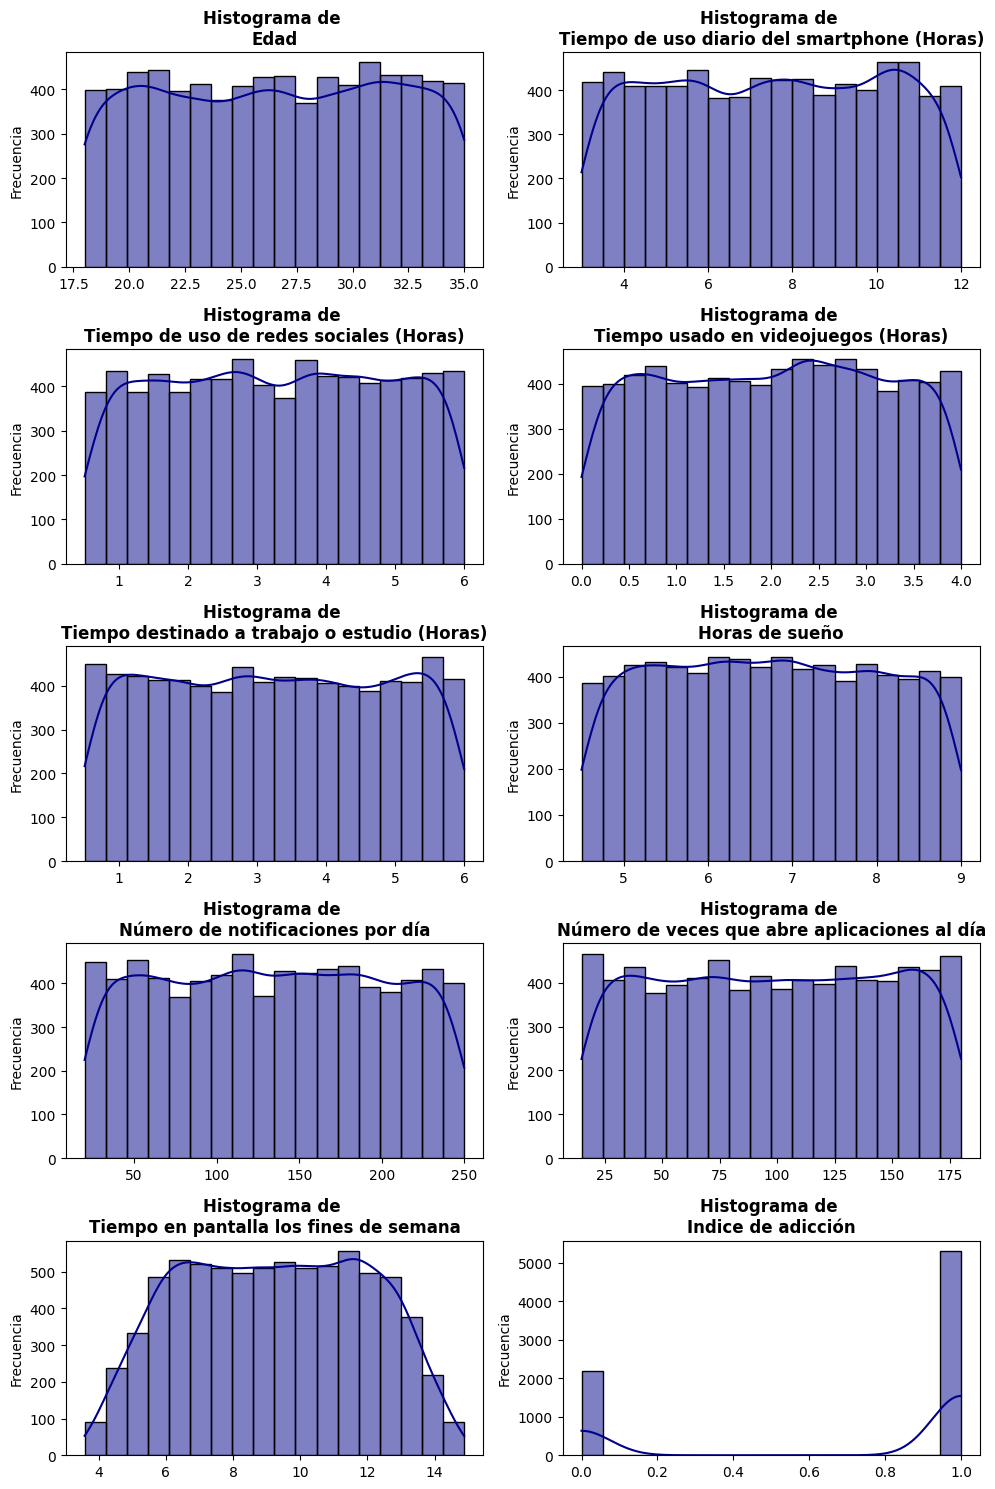

In [ ]:
fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(10,15))
axes=axes.flatten()

for i,col in enumerate(variables_numericas):
  sns.histplot(df[col], edgecolor="black",bins=18,  color="darkblue",kde=True, ax=axes[i])
  axes[i].set_ylabel("Frecuencia")
  axes[i].set_xlabel("")
  axes[i].set_title(f"Histograma de \n{col}",fontweight="bold")


plt.tight_layout()
plt.show()

Los histogramas permitieron evidenciar:
* **Edad:** El gráfico de barras permite evidenciar que el rango de edad de los individuos es de 18 a 35 años, sin embargo, se encuentra distribuidos de manera similar a una distribución uniforme, donde no se evidencia concentración de edades en determinados rangos en particular, y no se evidencia valores atipicos. Dado que el rango de la variable es de los 18 a 35 años, esto refleja que la muestra está conformada por individuos adolescentes, jovenes y adultos jovenes, sin ningun sesgo hacia un grupo determinado y en un rango relativamente pequeño.

* **Tiempo de uso diario del smartphone (Horas):**  Esta variable presenta un rango pequeño de 3 a 12 horas. Se evidencia una distribución similar a la uniforme, donde los datos se distribuyen a los largo del rango y no se evidencia concentraciones o grupos muy representivos, sin embargo se observa un pico de uso en el rango de 10 a 11 horas mostrando una pequeña asimetria negativa.

* **Tiempo de uso de redes sociales (Horas):**  No se observa un grupo caracteristico hacia donde se concentren los datos. Sin embargo, entre las 3 y 4 horas se observan frecuencias significativamente altas y bajas.

* **Tiempo usado en videojuegos (Horas):** Refleja una forma platicúrtica, sin embargo se identifican algunos picos en el intervalo de 2 a 3 horas.

* **Tiempo destinado a trabajo o estudio (Horas):** Refleja una distribución cercana a la uniforme donde los valores se encuentras dispersos en el dataset y no se evidencia grupos o concentraciones significativos. Se evidencian picos cercanos a 3 horas y también cercanos a 6 horas, pero el comportamiento está distribuido de forma general a lo largo de todo el rango.
Forma: distribución bimodal.

* **Horas de sueño:** El histograma muestra una distribución un poco similar a la uniforme, homogena, y donde no se tiende hacia un intervalo especifico. Los datos están distribuidos a lo largo de un rango pequeño entre 4 y 9 horas.

* **Número de notificaciones por día:** Se obsera que los datos presentan una homogeneidad relativa, con algunos picos en intervalos pequeños, sin embargo, no se evidencia una concentración significativa hacia donde especificamente tiendan los datos.


* **Número de veces que abre aplicaciones al día:** Se encuentran picos importantes cercanos a 15 y 75 en pequeños intervalos, sin embargo los datos se encuentran distribuidos a lo largo del rango y no hay una tendencia glogal hacia donde se concentren más los datos.

* **Tiempo en pantalla los fines de semana:** Es la principal variable que muestra una concentración agrupada más clara, donde los valores entre 6 y 12 horas son más frecuentes, por lo que tienden más hacia un intervalo que a la media.

**Generalidades:**
*  Mediante los histogramas se observa que las distribuciones tienden a ser más uniformes (a excepción de la variable tiempo en pantalla los fines de semana); no existe una tendencia hacia el valor promedio sino los datos se encuentran distribuidos de manera homogenea en el rango de los datos, y esto se evidencio cuando se encontró que la moda de las variables no coincidia con la mediana y media, característica común de una distribución normal.

### ***2.5 Exploración mediante boxplots:***

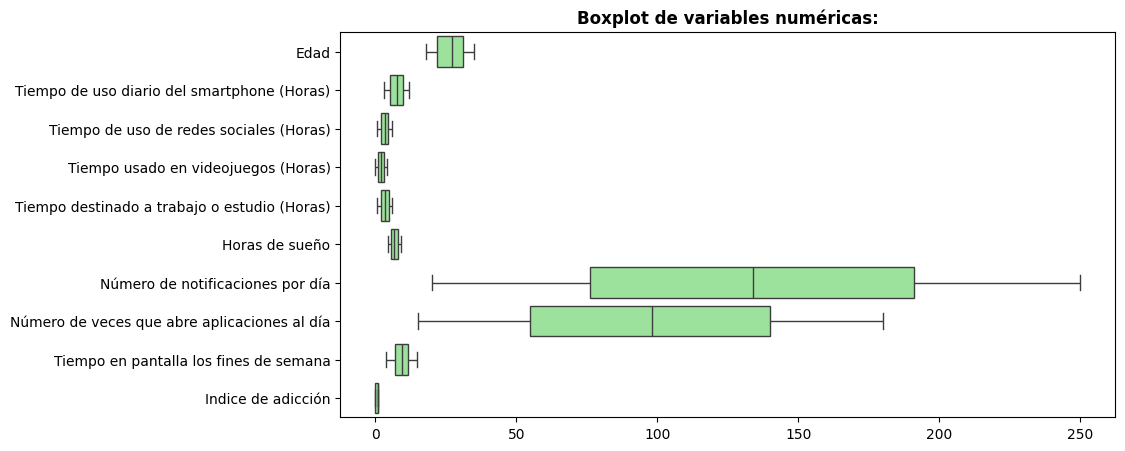

In [ ]:
plt.figure(figsize=(10,5))
sns.boxplot(df,color="lightgreen",orient="h")
plt.title("Boxplot de variables numéricas:", fontweight="bold")
plt.show()

La gráfica de boxplot permite identificar:
* En las variables numéricas de la base de datos no se identifican valores atipicos teniendo en cuenta el criterio de IQR respecto al 50% de la parte central de los datos de cada variable.
* Se observa que las variables 'Edad','Tiempo de uso diario del smartphone (Horas)','Tiempo de uso de redes sociales ','Tiempo usado en videojuegos',   'Tiempo destinado a trabajo o estudio', 'Horas de sueño','Tiempo en pantalla los fines de semana'e'Indice de adicción' presentan un tamaño de caja menor, mostrando que son datos más agrupados cercano a la media; los bigotes también son pequeños lo que muestra que el 25% de los datos cercanos al minimo y al máximo están muy cerca del rango central (50%) de los datos.
* El tamaño de la caja y de los bigotes tan grande de las variables Número de notificaciones por día y Número de veces que abre aplicaciones al día confirman que los datos están muy variables en estas variables, y al ser tan disperso en comparación con las demás variables, refleja la necesidad de escalar.
* Al visualizar la mediana de las variables Número de notificaciones por día y Número de veces que abre aplicaciones al día muestra que se encuentran aproximadamente en la mitad de la caja, indicando que no hay sesgos hacia determinados grupos.
* No se evidencian datos atipicos detectados por debajo o por encima de 1.5 el IQR.

Con el fin de analizar la mediana dentro de la caja de cada boxplot, se prefirió separar las variables de las de baja dispersión para hacerlas más visibles.

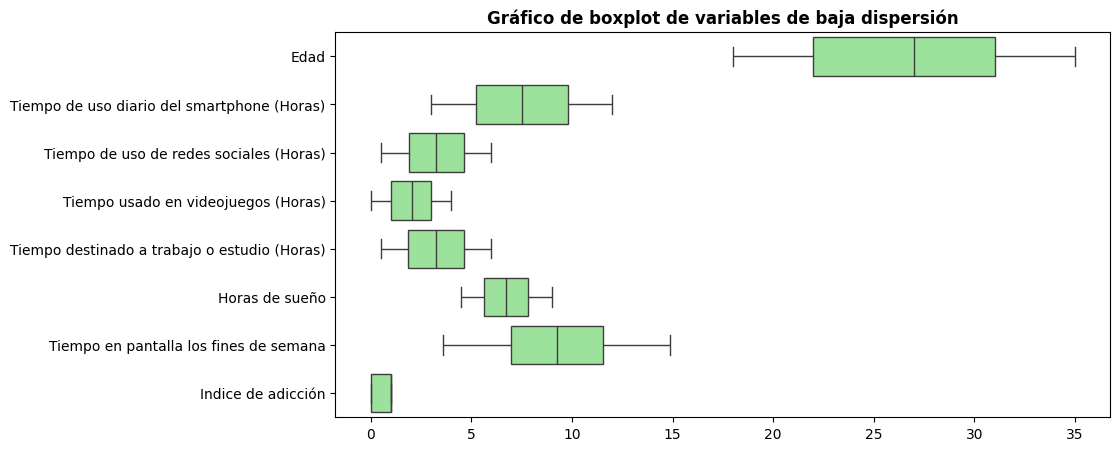

In [ ]:
var_baja_dispersion=['Edad','Tiempo de uso diario del smartphone (Horas)','Tiempo de uso de redes sociales (Horas)','Tiempo usado en videojuegos (Horas)',
           'Tiempo destinado a trabajo o estudio (Horas)', 'Horas de sueño','Tiempo en pantalla los fines de semana','Indice de adicción']
plt.figure(figsize=(10,5))
sns.boxplot(df[var_baja_dispersion],color="lightgreen",orient="h")
plt.title("Gráfico de boxplot de variables de baja dispersión", fontweight="bold")
plt.show()

Es posible observar:
* La mediana del boxplot de la variable edad muestra encontrarse un poco a la derecha, mostrando una mayor concentración de valores al lado izquierdo de la mediana, con un ligero sesgo hacia edades más pequeñas.
* La mediana de las variables Tiempo de uso diario del smartphone, Tiempo de uso de redes sociales, Tiempo usado en videojuegos, Tiempo destinado a trabajo o estudio, Horas de sueño y Tiempo en pantalla los fines de semana uestran que la mediana se encuentra en una posición aproximada de la mitad en la caja.

* La mediana de la variable Indice de adicción se presenta en 1, dado que es una variable binaria conformada por 0 y 1.

### ***2.6 Verificación de los niveles de variables categóricas:***

In [ ]:
for col in variables_categoricas:
  niveles=df[col].unique()
  print(niveles)

['Male' 'Other' 'Female']
['Medium' 'High' 'Low']
['Yes' 'No']
[nan 'Mild' 'Moderate' 'Severe']


In [ ]:
df.replace({"Male": "Hombre", "Female": "Mujer", "Other":"Otro","Medium":"Medio","High":"Alto","Low":"Bajo","Yes":"Si","Mild":"Leve","Moderate":"Moderado","Severe":"Severo"},inplace=True)

In [ ]:
for col in variables_categoricas:
  niveles=df[col].unique()
  print(niveles)

['Hombre' 'Otro' 'Mujer']
['Medio' 'Alto' 'Bajo']
['Si' 'No']
[nan 'Leve' 'Moderado' 'Severo']


Observamos que las variables categóricas significativas presentan los siguientes niveles:
* Género: Hombre, Mujer, Otro
* Nivel de estrés: Medio, Alto, Bajo
* Impacto sobre el rendimiento academico o  trabajo: Si y No
* Nivel de adicción: Leve, Moderado, Severo y valores nulos que se abordarán posteriormente.

### ***2.7 Exploración de variables cualitativas mediante gráficos de barras y diagrama de pie:***

In [ ]:
variables_categoricas.append("Indice de adicción") #Se decide agregar la variable de indice de adicción para poder visualizar su gráfico de barras y de tortas

/tmp/ipykernel_62357/2116879474.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col],order=orden,palette="pastel",ax=axis[i][0])
/tmp/ipykernel_62357/2116879474.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col],order=orden,palette="pastel",ax=axis[i][0])
/tmp/ipykernel_62357/2116879474.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col],order=orden,palette="pastel",ax=axis[i][0])
/tmp/ipykernel_62357/2116879474.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be remo

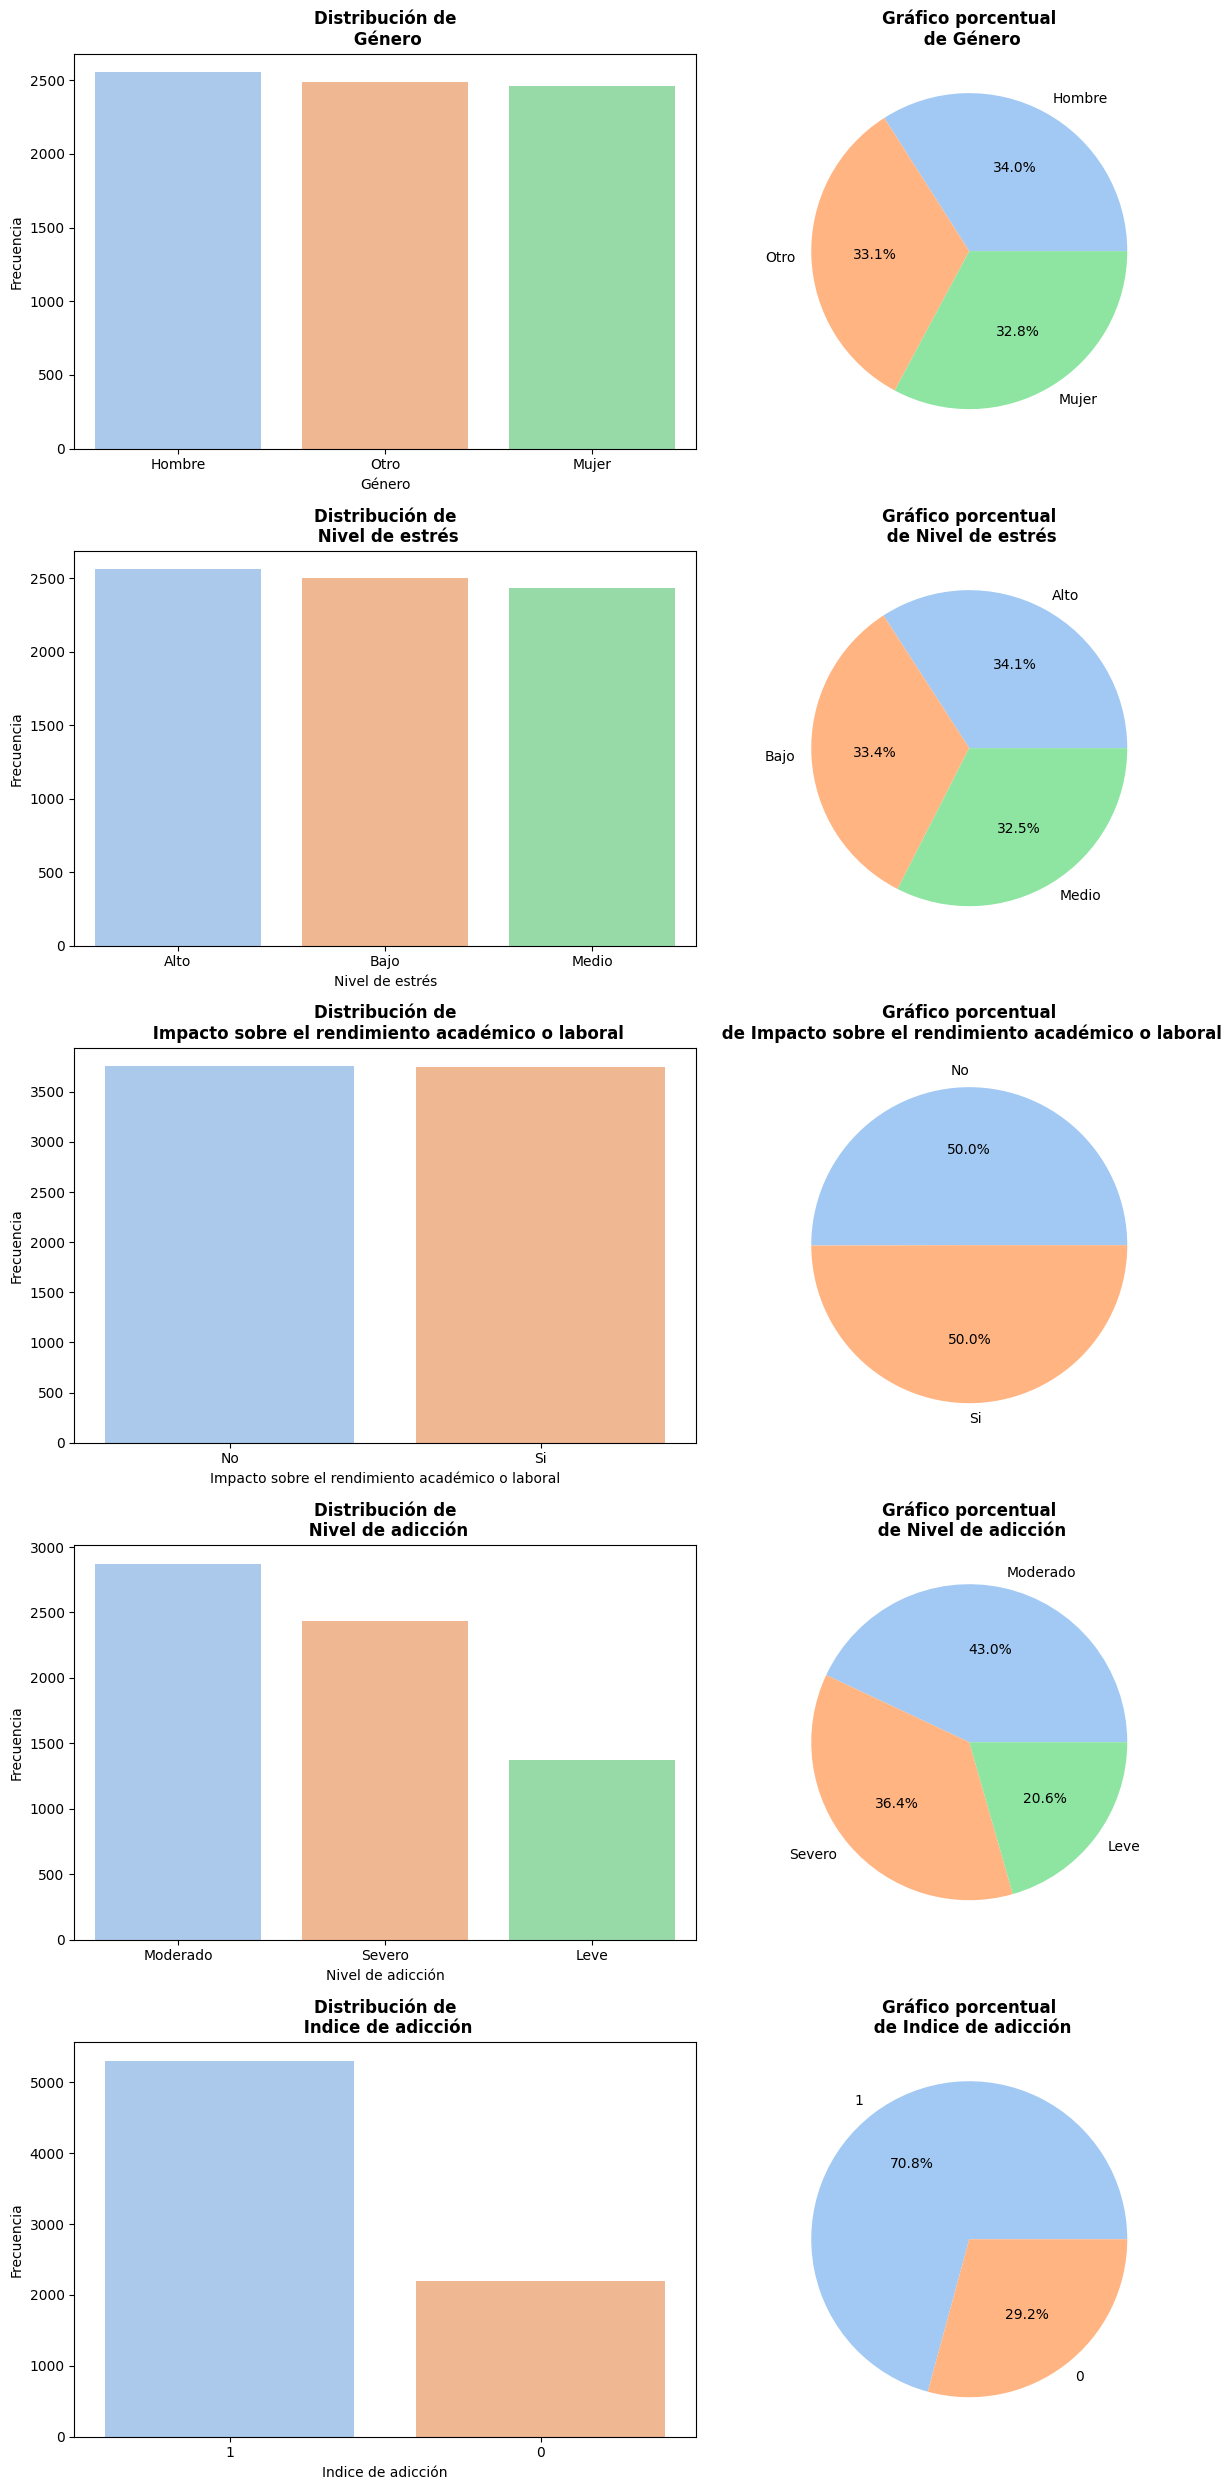

In [ ]:

fig,axis=plt.subplots(nrows=len(variables_categoricas),ncols=2,figsize=(13,25))
for i, col in enumerate(variables_categoricas):
  orden = df[col].value_counts().index #Se generó la variable orden para poder hacer coincidir en los colores las gráficas de barras y de tortas
  colores = sns.color_palette("pastel", n_colors=len(orden))
  sns.countplot(x=df[col],order=orden,palette="pastel",ax=axis[i][0])
  axis[i][0].set_title(f"Distribución de\n {col}",fontweight="bold")
  axis[i][0].set_ylabel("Frecuencia")

  conteo = df[col].value_counts().loc[orden]
  axis[i][1].pie(conteo,labels=conteo.index,autopct="%1.1f%%",colors=colores)
  axis[i][1].set_title(f"Gráfico porcentual\n de {col}", fontweight="bold")
plt.tight_layout()
plt.show()

Las gráficas de barras y de tortas permiten evidenciar:
* **Género:** La distribución de género por Hombre, Mujer y otro es muy similar, no hay una predominancia que genere sesgos.
* **Nivel de estrés:** La distribución de los niveles de estrés es muy pareja, solo existen pequeñas diferencias de 0.7% entre la categoria más alta (Alto) y la más baja (bajo)
* **Impacto sobre el rendimiento académico o laboral:** Se observa que la distribución es equitativa y pareja de 50% cada una.
* **Nivel de adicción:** Existe una leve predominancia del nivel moderado (38.3%) con relación al severo (32.5%) y leve (29.2%).
* **Indice de adiccón:** El gráfico de barras muestra que 5308 registros (equivalente a 70.77%) corresponden a individuos catalogados con un índice de adicción moderado o severo. Por otra parte, 2192 registros (equivalentes al 29.23%) son categorizados con un nivel de adicción leve. Es importante recordar que esta variable cuantitativa (y su equivalente "Nivel de adicción") es la variable dependiente (Y) y es la que se utilizará también para entrenar el modelo y una vez validado se podrá utilizar para predecir resultados.

## **Paso 3. Reporte de la calidad de los datos:**

### ***3.1 Determinación de registros duplicados:***

In [ ]:
df.duplicated().sum()

np.int64(0)

Se evidencia que la base de datos no presenta registros duplicados.

### ***3.2 Determinación y tratamiento de valores nulos:***

In [ ]:
(df.isnull().sum()/df.isnull().count())*100 #Porcentaje de valores nulos: primero con isnull() evalúo si es un valor nulo donde  1 es verdadero y 0 es falso. Luego con el promedio sumo y divido por el total de los datos

,0
ID Transacción,0.00
ID Usuario,0.00
Edad,0.00
Género,0.00
Tiempo de uso diario del smartphone (Horas),0.00
Tiempo de uso de redes sociales (Horas),0.00
Tiempo usado en videojuegos (Horas),0.00
Tiempo destinado a trabajo o estudio (Horas),0.00
Horas de sueño,0.00
Número de notificaciones por día,0.00


Se identifica que el 11% de los datos del nivel de adicción son nulos, por lo cual surge la necesidad de revisar los registros completos que contienen estos valores nulos.

In [ ]:
# Registros con valores nulos
df[df["Nivel de adicción"].isnull()] #Con el método .isnull() evalúo cada valor de la columna "Nivel de adicción" para verificar con booleano si es o no un valor nulo, y como mascara en pandas la utilizo para filtrar unicamente los True

,ID Transacción,ID Usuario,Edad,Género,Tiempo de uso diario del smartphone (Horas),Tiempo de uso de redes sociales (Horas),Tiempo usado en videojuegos (Horas),Tiempo destinado a trabajo o estudio (Horas),Horas de sueño,Número de notificaciones por día,Número de veces que abre aplicaciones al día,Tiempo en pantalla los fines de semana,Nivel de estrés,Impacto sobre el rendimiento académico o laboral,Nivel de adicción,Indice de adicción
0,TXN00001,U00001,21,Hombre,3.23,2.01,0.89,4.55,7.55,248,154,3.95,Medio,Si,NaN,0
1,TXN00002,U00002,24,Otro,5.09,3.81,2.24,4.44,7.66,127,71,6.71,Medio,Si,NaN,0
8,TXN00009,U00009,21,Otro,4.38,1.38,2.72,3.78,6.23,172,134,6.20,Alto,Si,NaN,0
11,TXN00012,U00012,27,Otro,5.16,1.82,2.27,0.93,7.79,228,32,8.10,Alto,Si,NaN,0
13,TXN00014,U00014,32,Hombre,4.09,1.74,1.35,3.74,5.54,76,16,4.77,Alto,Si,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7447,TXN07448,U07448,20,Mujer,5.00,1.68,2.87,1.02,6.67,237,26,5.87,Medio,Si,NaN,0
7454,TXN07455,U07455,29,Otro,3.45,3.95,1.20,1.24,7.51,25,84,5.19,Alto,No,NaN,0
7457,TXN07458,U07458,29,Mujer,3.11,2.44,3.17,0.84,8.93,217,174,4.27,Alto,Si,NaN,0
7481,TXN07482,U07482,29,Hombre,4.72,3.65,0.78,2.58,5.15,20,76,6.02,Medio,No,NaN,0


Si se revisa nuevamente la base de datos original, es posible identificar que la variable "Nivel de adicción" es correspondiente y equivalente al valor del índice de adicción. Donde:
* Si el índice = 0, el nivel de adicción es leve
* Si el índice = 1, se conoce que el nivel de adicción es Moderado o severo

Por lo cual verificamos de manera simultanea la variable nivel de adicción como criterio para complementar:

In [ ]:
#Conteo de NA en la variable "Nivel de adicción"
#Cuando "Indice de  adicción == 0"
((df["Indice de adicción"]==0)&(df["Nivel de adicción"].isnull())).sum()


np.int64(819)

In [ ]:
#Cuando el "Indice de adicción == 1"
((df["Indice de adicción"]==1) & (df["Nivel de adicción"].isnull())).sum()

np.int64(0)

Vemos que todos los registros nulos de la variable "Nivel de adicción" (819) corresponden a individuos cuyo "Indice de adicción" es igual a 0. Por lo cual, utilizando el criterio anteriormente mencionado, se reemplazaran todos los NA por Leve.

In [ ]:
df["Nivel de adicción"]=df["Nivel de adicción"].fillna("Leve")

In [ ]:
#Verificamos el porcentaje de valores nulos luego del reemplazo
(100*df.isnull().sum()/(df.count())).round(2)

,0
ID Transacción,0.0
ID Usuario,0.0
Edad,0.0
Género,0.0
Tiempo de uso diario del smartphone (Horas),0.0
Tiempo de uso de redes sociales (Horas),0.0
Tiempo usado en videojuegos (Horas),0.0
Tiempo destinado a trabajo o estudio (Horas),0.0
Horas de sueño,0.0
Número de notificaciones por día,0.0


De esta manera hemos podido abordar los valores nulos presentes en la base de datos.


## **Paso 4: Análisis de la variable dependiente y de las relaciones entre variables mediante matriz de correlación y análisis bivariado:**

### ***4.1 Variable dependiente (Indice de adicción):***

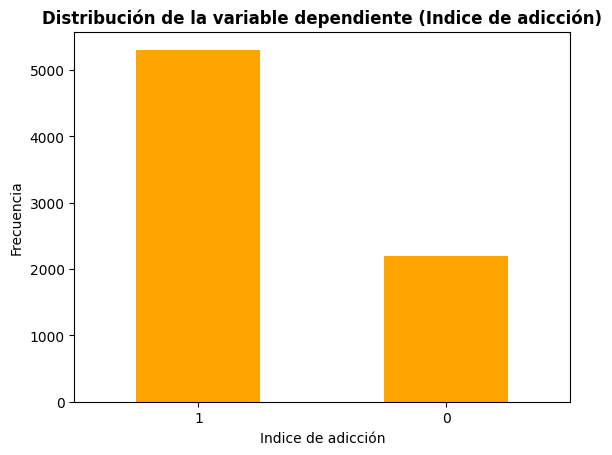

In [ ]:
conteo = df["Indice de adicción"].value_counts()
conteo.plot(kind="bar",color="orange")
plt.xticks(rotation=0)
plt.title("Distribución de la variable dependiente (Indice de adicción)", fontweight="bold")
plt.ylabel("Frecuencia")
plt.show()

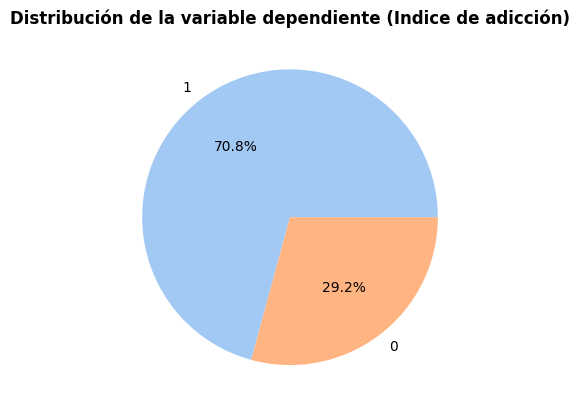

In [ ]:
plt.pie(conteo,labels=conteo.index,autopct="%1.1f%%",colors=colores)
plt.title("Distribución de la variable dependiente (Indice de adicción)", fontweight="bold")
plt.show()

Con relación a la variable predictoria, es posible identificar que la base de datos presenta un desbalance hacia un nivel de adicción moderado/severo (indice de adicción) y una menor cantidad de registros con nivel de adicción bajo (indice de adicción = 0).
Razo por la cual, el modelo a construir podrá tener la tendencia de predecir mejor los casos moderados/severos que los leves. Teniendo en cuenta este desbalance, se toma la decisión de utilizar **validación estratificada** en lugar de validación cruzada simple para garantizar la representatividad de los casos leves en cada muestra al mantenerla proporción de las clases.

### ***4.1 Matriz de correlación:***

Con el fin de analizar la posible relación entre variables se decidió utilizar un mapa de calor de la correlación calculada entre las variables numéricas de la base de datos.

<Axes: >

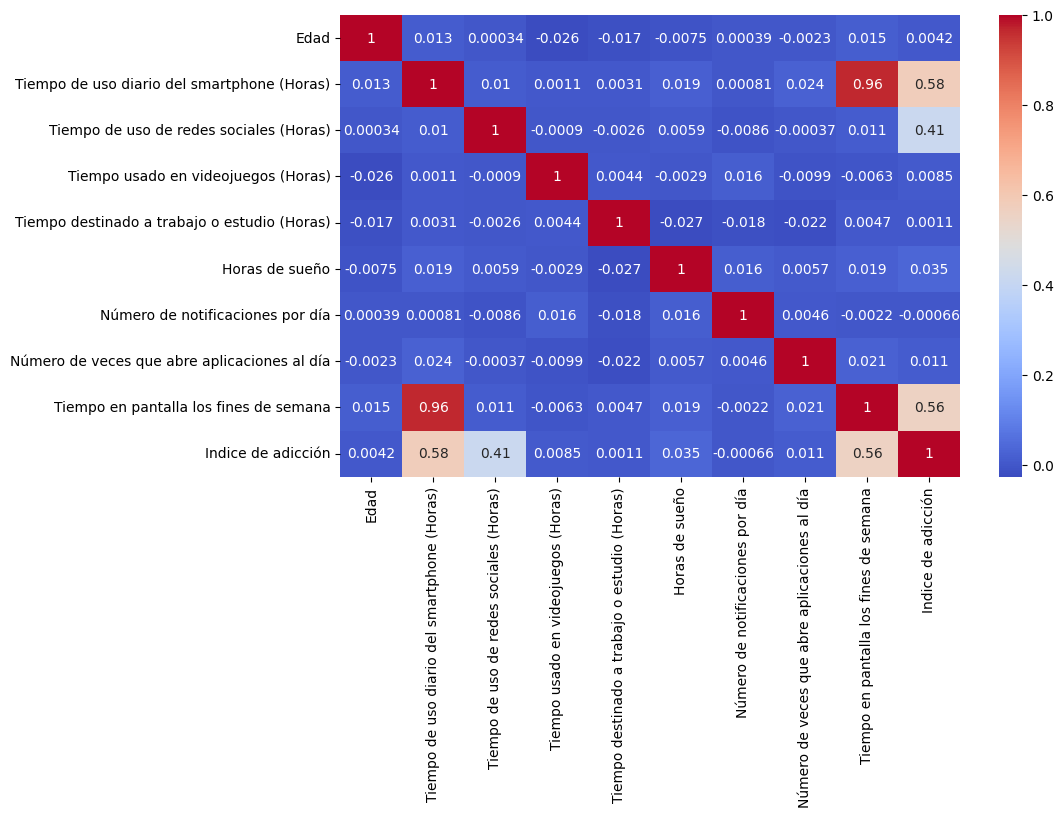

In [ ]:
variables_numericas=df.select_dtypes(include=[np.number]).columns.tolist()

df[variables_numericas].corr()
plt.figure(figsize=(10,6))
sns.heatmap(df[variables_numericas].corr(),annot=True,cmap="coolwarm")


El mapa de calor permite determinar:
* Una correlación fuerte y positiva entre las variables tiempo de uso diario del smartphone y tiempo en pantalla los fines de semana. Indicando que aquellos usuarios que utilizan el celular en alta intensidad de manera diaria, también lo hacen los fines de semana.
* Se observa correlaciones bajas entre la edad y las demás variables, indicando que la edad en este caso no es un factor que tan determinante o influyente en las demás variables.
* Se muestra una correlación positiva moderada entre el índice de adicción y el tiempo de uso diario del smartphone (0.58), con el Tiempo en redes sociales (0.41) y  el tiempo en pantalla los fines de semana (0.56). Esto parece demostrar que son las variables más influyentes para categorizar el nivel de adicción en el individuo.

**De coeficiente de correlación de Pearson de posibles variables independientes con la variable a predecir Indice de adicción:**

* Se observa que las variables "Edad", "Tiempo usado en video juegos", "Tiempo destinado a trabajo o estudio, "Número de notificaciones al dia" y "Número de veces que abre aplicaciones al día" presentan una correlación muy baja con la variable indice de adicción.

* Debido a la alta correlación entre **Tiempo de de uso diario del smarttphone** y del **Tiempo en pantalla los fines de semana** y los problemas de multicolinealidad y redundancia que se pueda generar, se decide descartar la variable **Tiempo en pantalla los fines de semana*.

* Las variables **"Tiempo de uso diario del smartphone", "Tiempo de uso en redes sociales"** presentan una correlación debil y moderada positiva con la variable indide de adicción, generando las correlaciones más significativas entre todas las variables de la base de datos, por lo cual son las candidatas para la aplicación de modelos de clasificación.



### ***4.2 Análisis bivariado:***

Se realizará un análisis bivariado con el fin de analizar y entender mejor el comportamiento de las variables,

In [ ]:
variables_categoricas

['Género',
 'Nivel de estrés',
 'Impacto sobre el rendimiento académico o laboral',
 'Nivel de adicción',
 'Indice de adicción']

> ### ***4.2.1 Análisis de variables cualitativas:***

> > ##### **Género e índice de adicción:** Se observa que el génermo masculino muestra una predominancia en los casos de adicción moderado/severo, mientras que en los casos leves predomina el género no indicado (otro).
Por lo cual, el género será una variable a introducir dentro del modelo.

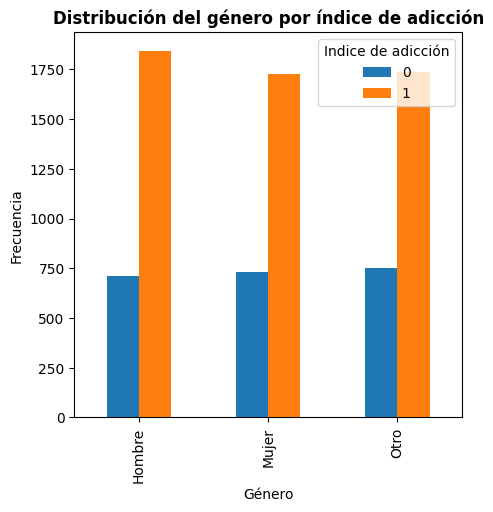

In [ ]:
tabla_genero_adiccion=pd.crosstab(df["Género"],df["Indice de adicción"])

tabla_genero_adiccion.plot(kind="bar",figsize=(5,5))
plt.title("Distribución del género por índice de adicción", fontweight="bold")
plt.ylabel("Frecuencia")
plt.show()

In [ ]:
tabla_genero_adiccion

Indice de adicción,0,1
Género,,
Hombre,709,1844
Mujer,733,1728
Otro,750,1736


> > ##### **Nivel de estrés e índice de adicción:** Se evidencia una predominancia en el nivel de adiccion (leve/moderado/severo)cuando el nivel de estrés es alto.

Por lo cual, el género será una variable a introducir dentro del modelo.

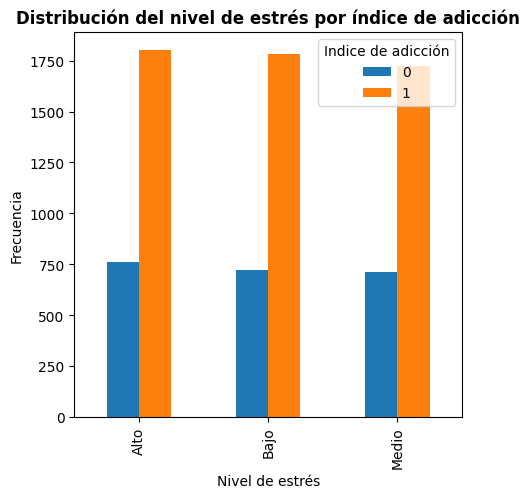

In [ ]:
tabla_estres_adiccion=pd.crosstab(df["Nivel de estrés"],df["Indice de adicción"])

tabla_estres_adiccion.plot(kind="bar",figsize=(5,5))
plt.title("Distribución del nivel de estrés por índice de adicción", fontweight="bold")
plt.ylabel("Frecuencia")
plt.show()

In [ ]:
tabla_estres_adiccion

Indice de adicción,0,1
Nivel de estrés,,
Alto,759,1801
Bajo,721,1782
Medio,712,1725


> > ##### **Impacto sobre el rendimiento académico o laboral e índice de adicción:** Se evidencia que la variable no influye en la determinación de si el nivel de adicción es leve (0) o moderado/severo (1) de manera significativa, por lo cual, no es una variable que se considerará en el modelo.

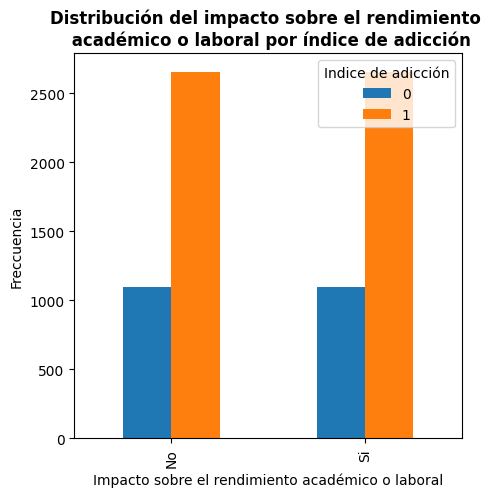

In [ ]:
tabla_academico_adiccion=pd.crosstab(df["Impacto sobre el rendimiento académico o laboral"],df["Indice de adicción"])

tabla_academico_adiccion.plot(kind="bar",figsize=(5,5))
plt.title("Distribución del impacto sobre el rendimiento \n académico o laboral por índice de adicción",fontweight="bold")
plt.ylabel("Freccuencia")
plt.show()

In [ ]:
tabla_academico_adiccion

Indice de adicción,0,1
Impacto sobre el rendimiento académico o laboral,,
No,1097,2656
Si,1095,2652


> ### ***4.2.2 Análisis de variables cuantitativas de importancia:***

##### **Tiempo de uso diario del smartphone vs nivel de adicción:**

In [ ]:
df.columns

Index(['ID Transacción', 'ID Usuario', 'Edad', 'Género',
       'Tiempo de uso diario del smartphone (Horas)',
       'Tiempo de uso de redes sociales (Horas)',
       'Tiempo usado en videojuegos (Horas)',
       'Tiempo destinado a trabajo o estudio (Horas)', 'Horas de sueño',
       'Número de notificaciones por día',
       'Número de veces que abre aplicaciones al día',
       'Tiempo en pantalla los fines de semana', 'Nivel de estrés',
       'Impacto sobre el rendimiento académico o laboral', 'Nivel de adicción',
       'Indice de adicción'],
      dtype='object')

/tmp/ipykernel_62357/4141471642.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Nivel de adicción",y="Tiempo de uso diario del smartphone (Horas)", data=df,palette="pastel")


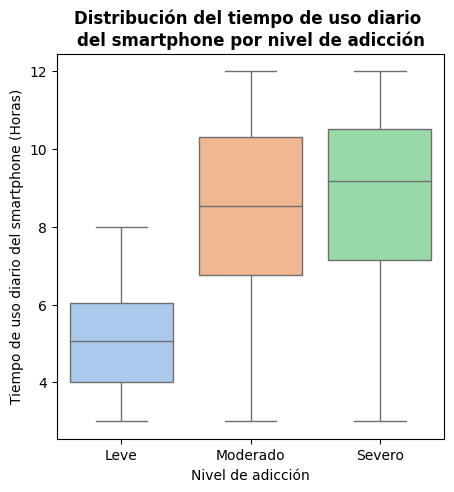

In [ ]:
plt.figure(figsize=(5,5))
sns.boxplot(x="Nivel de adicción",y="Tiempo de uso diario del smartphone (Horas)", data=df,palette="pastel")
plt.title("Distribución del tiempo de uso diario \ndel smartphone por nivel de adicción", fontweight="bold")
plt.show()

Se identifica que de acuerdo al tiempo de uso del teléfono se clasifica el nivel de adicción en dos categorías: leve(0) y moderado/severo (1).

#####**Tiempo de uso diario del smartphone vs género:**

/tmp/ipykernel_62357/716137947.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Género",y="Tiempo de uso diario del smartphone (Horas)", palette="pastel", data=df)


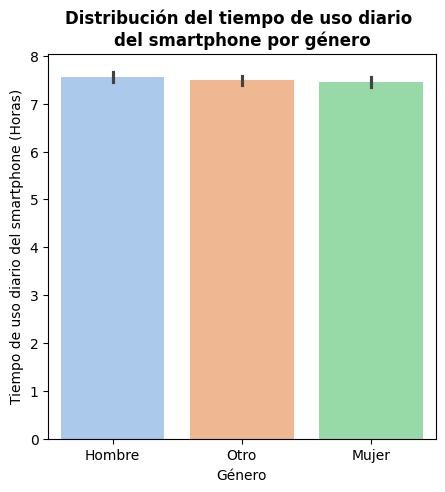

In [ ]:
plt.figure(figsize=(5,5))
sns.barplot(x="Género",y="Tiempo de uso diario del smartphone (Horas)", palette="pastel", data=df)
plt.title("Distribución del tiempo de uso diario \ndel smartphone por género", fontweight="bold")
plt.show()

Se identifica que el tiempo de uso diario del teléfono se distribuye de manera equitativa en el género.

##### **Tiempo de uso de redes sociales y tiempo de uso diario del smartphone:**

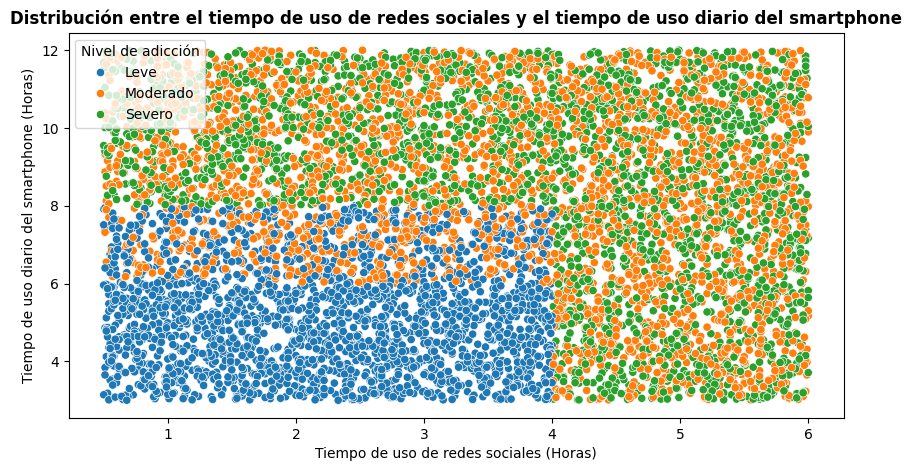

In [ ]:
plt.figure(figsize=(10,5))
sns.scatterplot(x="Tiempo de uso de redes sociales (Horas)",y="Tiempo de uso diario del smartphone (Horas)", hue="Nivel de adicción", data=df)
plt.title("Distribución entre el tiempo de uso de redes sociales y el tiempo de uso diario del smartphone", fontweight="bold")
plt.show()

Se evidencia un patrón donde el nivel de adicción leve se caracteriza por tiempo de uso diario del smartphone de 0 hasta 8 horas y un tiempo en redes sociales de 0 a 4 horas.
En segundo lugar, el nivel de adicción incrementa a moderado si el individuo presenta un tiempo de uso diario entre 6 y 12 horas y tiempo en redes sociales entre 4 y 6 horas.
Y en tercer lugar el nivel de adicción severo se presenta únicamente cuando el tiempo de uso diario es de 8 horas hasta 12 horas y el tiempo en redes sociales es de 4 a  6 horas.
Esta gráfica muestra la estrecha relación entre índice de adicción y el tiempo destinado para redes sociales, así como la relación entre índice de adicción y el tiempo de uso diario del smartphone especialmente para separar los niveles leves de los severos.


##### **Conclusiones generales del análisis exploratorio de datos:**
*   Se realizó el proceso de validación, limpieza y tratamiento de los datos que incluyó determinación de registros duplicados, tratamiento de valores nulos, escalamiento de variables y detección de valores nulos.
*   Se identificó que las mayoria de variables son uniformes. Las variables de mayor influencia en la determinación o clasificación del nivel de adicción son el **Tiempo de uso diario del smartphone,  Tiempo de uso en redes sociales, el género y el nivel de estrés.  Las demás variables como la edad, las horas de sueño, el tiempo en video juegos o si existe impacto sobre el rendimiento académico o laboral** presentan baja influencia en la clasificación de los individuos por nivel de adicción y por lo cual son óptimas **para ingresar al modelo**.




## **Paso 5: Preparación preliminar:**

### ***5.1 Selección de variables:***

Inicialmente defino las variables preduictorias (x) y la variable dependiente (y). Y aplico codificación One Hot Encoding que se aplicará unicamente a las variables categoricas del listado.

In [ ]:
variables_predictorias = ['Tiempo de uso diario del smartphone (Horas)', 'Tiempo de uso de redes sociales (Horas)',
                          'Género',  'Nivel de estrés']

In [ ]:
y=df["Indice de adicción"]
x=pd.get_dummies(df[variables_predictorias]) #Se convierte unicamente las variables categoricas en variables binarias (True:1 False:0)

In [ ]:
x

,Tiempo de uso diario del smartphone (Horas),Tiempo de uso de redes sociales (Horas),Género_Hombre,Género_Mujer,Género_Otro,Nivel de estrés_Alto,Nivel de estrés_Bajo,Nivel de estrés_Medio
0,3.23,2.01,True,False,False,False,False,True
1,5.09,3.81,False,False,True,False,False,True
2,6.06,1.36,False,False,True,True,False,False
3,7.83,5.85,False,False,True,True,False,False
4,9.96,5.92,True,False,False,False,True,False
...,...,...,...,...,...,...,...,...
7495,9.85,1.75,False,False,True,False,True,False
7496,5.67,2.33,True,False,False,False,True,False
7497,9.99,3.61,False,True,False,False,False,True
7498,8.74,1.59,True,False,False,True,False,False


### ***5.2 División de los datos en entrenamiento y prueba:***

Se realiza la división de los datos bajo el criterio 70% para entrenamiento y 30% para prueba. Se realiza la división bajo el método estratificado para mantener la proporción de las  clases (indice de accion 0 y 1) teniendo en cuenta el desbalance de casos 1 sobre el 0.

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.30,
                                                    random_state=0,
                                                    stratify=y) #división estratificada

In [ ]:
print("Tamaño x_train:", x_train.shape)
print("Tamaño x_test:", x_test.shape)
print("Tamaño y_train:", y_train.shape)
print("Tamaño y_test:", y_test.shape)

Tamaño x_train: (5250, 8)
Tamaño x_test: (2250, 8)
Tamaño y_train: (5250,)
Tamaño y_test: (2250,)


### ***5.3 Estandarización:***

Despues de dividir los datos en los de entrenamiento y prueba se realiza la estandarización mediante z-score.
Dado que las variables categoricas se encuentran codificadas de manera binaria (False:0 y True:1) no requieren escalamiento

In [ ]:
#Lista de columnas numericas a escalar
columnas_numericas = [
    'Tiempo de uso diario del smartphone (Horas)',
    'Tiempo de uso de redes sociales (Horas)']


In [ ]:
#Genero una copia de x_train y x_test
x_train_scaled =x_train.copy()
x_test_scaled = x_test.copy()

#Estandarizo unicamentelas columnas numericas, no las que provienen de variables categoricas
scaler=StandardScaler()
x_train_scaled[columnas_numericas]= scaler.fit_transform(x_train[columnas_numericas])
x_test_scaled[columnas_numericas]= scaler.fit_transform(x_test[columnas_numericas])

### ***5.4 Definición de parámetros de validación cruzada estratificada***

In [ ]:
#Parametros para validación cruzada estratificada (mnteniendo la proporción de clases)
cv = StratifiedKFold(
    n_splits=5, #Divido los datos en 5 folds
    shuffle=True, #Mezzcla aleatoria
    random_state=0)


## **Paso 6: Aplicación de modelos de clasificación:**

### ***6.1 Regresión logistica:***

Para la generación del modelo de clasificación mediante regresión logistica se aplicó primero la herramienta GridSearchCV con el fin de buscar automaticamente la mejor combinación de hiperparámetros usando validación cruzada estratificada.

In [ ]:
param_grid_lg = {
    "C":[0.01,0.1,1,10], #parametros de regularización que se probaran
    "class_weight":[None,"balanced"]}# Definicion de la importancia de la clase (None: todas las observaciones mismo peso, balanced: peso mayor para la clase minoritaria)

#
grid_logistico = GridSearchCV(
    LogisticRegression(max_iter=1000), #Por regresión logistica
    param_grid = param_grid_lg,  #Parametros previamente definidos a probar
    cv=cv,  #Esquema de validación cruzada a probar
    scoring="f1", #metrica para que defina cual es el mejor modelo. F1 combina precision y recall
    n_jobs=-1) #controla la cantidad de nucleos que el procesador va a utilizar (todos)

grid_logistico.fit(x_train_scaled,y_train) #Pruebo las combinaciones de param_grid_lg, y para cada una aplico validación cruzada, y evalua el modelo usando la metrica F1
grid_logistico.best_params_  #Obtención de mejores parámetros

{'C': 0.01, 'class_weight': None}

La regresión logística fue optimizada mediante GridSearchCV. Se evaluaron diferentes niveles de regularización (C) y esquemas de ponderación de clases (class_weight) utilizando validación cruzada estratificada de cinco particiones. La selección del modelo se realizó con base en el F1-score promedio, empleando todos los núcleos disponibles del procesador para acelerar el proceso de búsqueda.

In [ ]:
#Generación del modelo con los parámetros de mejor  resultado encontrados (best_params)
modelo_logistico = grid_logistico.best_estimator_

#Predecir a partir de los datos de prueba
y_pred_logistico = modelo_logistico.predict(x_test_scaled)

Con el fin de evaluar el modelo de clasificación generado se genero la matriz de confusión y se calcularon como metricas de evaluación el accuracy, recall, precision y f1-score.

In [ ]:
#Matriz de confusión
cm_logistico = confusion_matrix(y_test,y_pred_logistico)
cm_logistico = pd.DataFrame(cm_logistico,
                            index=["Real 0","Real 1"],
                            columns=["Predicho 0","Predicho 1"])
cm_logistico

,Predicho 0,Predicho 1
Real 0,489,169
Real 1,83,1509


**Métricas:**
* **Accuracy:** Proporción de observaciones correctamente clasificadas respecto al total de observaciones evaluadas. Mide el desempeño global del modelo. Verdaderos positivos y verdaderos negativos sobre el total
* **Precisión:** proporción de observaciones clasificadas como positivas que realmente pertenecen a la clase positiva. Evalúa la confiabilidad de las predicciones positivas.
* **Recall (Sensibilidad o Tasa de Verdaderos Positivos):** proporción de observaciones positivas reales que son correctamente identificadas por el modelo. Mide la capacidad para detectar los casos positivos.
* **F1-Score:** Permite evaluar simultáneamente la precision y el recall y es especialmente útil cuando existe desbalance entre clases.

In [ ]:
#Métricas
accuracy_logistico = accuracy_score(y_test,y_pred_logistico)
precision_logistico = precision_score(y_test,y_pred_logistico)
recall_logistico = recall_score(y_test,y_pred_logistico)
f1_logistico = f1_score(y_test,y_pred_logistico)

In [ ]:
print(classification_report(y_test,y_pred_logistico))

              precision    recall  f1-score   support

           0       0.85      0.74      0.80       658
           1       0.90      0.95      0.92      1592

    accuracy                           0.89      2250
   macro avg       0.88      0.85      0.86      2250
weighted avg       0.89      0.89      0.89      2250



Considerando ambas clases con la misma importancia, el modelo alcanza un desempeño promedio de 0.86 en términos de F1-score. Pero, considerando la distribución real de las clases en la muestra, el modelo alcanza un F1-score global de 0.89.
Por lo cual, de manera general el El modelo presenta un desempeño equilibrado entre ambas clases, ya que las métricas promedio macro y ponderada son similares.

Se realizó tambien la determinación de coeficientes y odd_rattio para el modelo.

In [ ]:
#Coeficientes del modelo
coeficientes_lg = pd.DataFrame({
    "Variable:":x.columns,
    "Coeficientes:":modelo_logistico.coef_[0]})

#Cálculo de odd ratio
coeficientes_lg["Odds_Ratio"]=np.exp(coeficientes_lg["Coeficientes:"])
coeficientes_lg

,Variable:,Coeficientes:,Odds_Ratio
0,Tiempo de uso diario del smartphone (Horas),1.814842,6.140107
1,Tiempo de uso de redes sociales (Horas),1.315092,3.725093
2,Género_Hombre,0.018324,1.018493
3,Género_Mujer,0.044363,1.045362
4,Género_Otro,-0.061914,0.939964
5,Nivel de estrés_Alto,-0.061194,0.940641
6,Nivel de estrés_Bajo,-0.005663,0.994353
7,Nivel de estrés_Medio,0.067630,1.069970


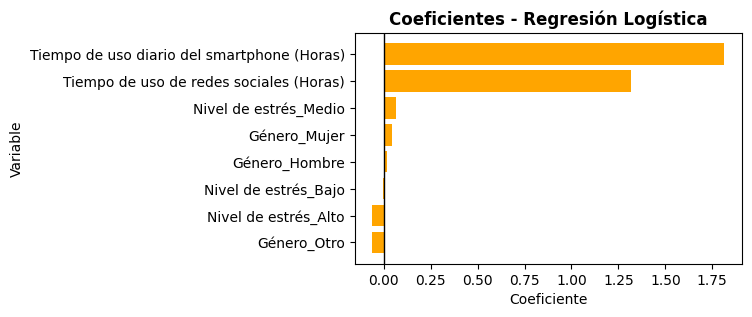

In [ ]:
coeficientes_lg =coeficientes_lg.sort_values(by="Odds_Ratio",ascending=True)
plt.figure(figsize=(5,3))
plt.barh(coeficientes_lg["Variable:"], coeficientes_lg["Coeficientes:"], color="orange")

plt.axvline(0, color="black", linewidth=1)
plt.title("Coeficientes - Regresión Logística", fontweight="bold")
plt.xlabel("Coeficiente")
plt.ylabel("Variable")
plt.show()

In [ ]:
#Intercepto del modelo
intercepto_lg=modelo_logistico.intercept_[0]
print("Intercepto",intercepto_lg)

Intercepto 1.6239443511706215


* **Interpretación de los coeficientes:**
Mediante el análisis de las metricas se identifica que a mayo tiempo de uso diario del smartphone y mayor tiempo de uso de redes sociales mayor es mayor el riesgo de adiccion (1).

Por otro lado, los coeficientes muestran una influencia menor del género en el indice de adicción, donde  los géneros hombre y mujer definidos presentan muestran un leve riesgo mayor de adicción que los individuos que no indicaron el género.

Por último, se identifica que el nivel de estres medio muestra un nivel de influencia leve en el indice de adicción. Sin embargo, el nivel de estres alto refleja un menor riesgo de adicción.

* **Interpretación del intercepto:**
El intercepto muestra una  tendencia inicial del modelo hacia la clase 1.

* **Interpretación de los Odds Ratio:**
  * Un incremento de una unidad de desviacion estandar en el tiempo de uso diario del smartphone se asocia con un aumento aproximado del 514% en las odds de presentar adicción al smartphone.
  * Un incremento de una unidad en la desviación estandar en el uso de redes sociales se asocia con un aumento aproximado del 272% en las odds de presentar adicción al smartphone.
  *Los hombres presentan unas odds de adicción aproximadamente 1.8% mayores que las mujeres y los individuos que no indicaron especificamente el género.
  *Los mujeres presentan unas odds de adicción aproximadamente 4.5% mayores que las hombres u del género otros.
  * Las personas con estrés alto presentan unas odds de adicción aproximadamente 6% menores que las personas con estrés bajo, manteniendo constantes las demás variables.
  * Las personas con estrés medio tienen unas odds de adicción aproximadamente 6.9% mayores que las personas con estrés bajo.


Se aplicó también la curva de ROC y AUC para evaluar el modelo. En esta se determinar que cuanto más cerca esté la curva de la esquina superior izquierda, mejor.


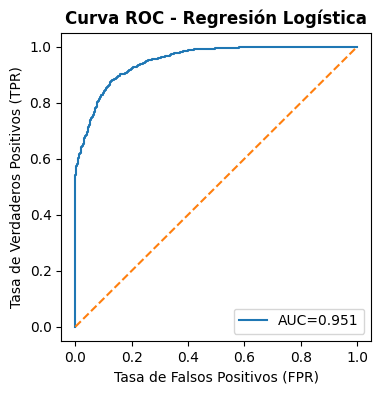

In [ ]:
#Curva ROC y AUC

y_prob_logistico = modelo_logistico.predict_proba(x_test_scaled)[:,1]  #Probabilidadesde la clase 1
fpr_logistico,tpr_logistico,_ = roc_curve(y_test,y_prob_logistico)
auc_logistico = roc_auc_score(y_test,y_prob_logistico)

plt.figure(figsize=(4,4))
plt.plot(fpr_logistico,tpr_logistico,label=f"AUC={auc_logistico:.3f}")
plt.plot( [0,1], [0,1], linestyle="--")
plt.xlabel("Tasa de Falsos Positivos (FPR)")
plt.ylabel("Tasa de Verdaderos Positivos (TPR)")
plt.title("Curva ROC - Regresión Logística",fontweight="bold")
plt.legend()

plt.show()

El área bajo la curva ROC (AUC) es cercano a 1, lo que indica que el modelo tiene muy buena capacidad para discriminar un caso 0 y un caso 1.

Por último se elaboró la curva de precision-Recall del modelo.

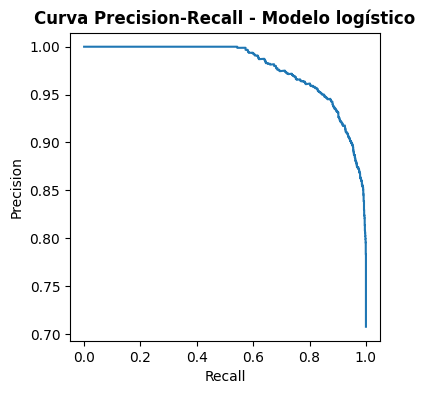

In [ ]:
#Curva precision-recall modelo logistico
precision_pr_logistico, recall_pr_logistico, _ = precision_recall_curve(y_test, y_prob_logistico)
plt.figure(figsize=(4,4))
plt.plot(recall_pr_logistico, precision_pr_logistico)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Curva Precision-Recall - Modelo logístico",fontweight="bold")
plt.show()



In [ ]:
#help(LogisticRegression)

### ***6.2 Arboles de decisión:***

El modelo del árbol de decisión funciona bajo un algoritmo de aprendizaje supervisado no paramétrico. Se caracteriza por tener una estructura jerárquica de árbol, que consta de un nodo raiz, ramas, nodos internos y nodos hojas.

In [ ]:
param_grid_arbol = {
    "max_depth":[3,4,5,6,7], #Control de profundidad máxima. Máximo 7 niveles
    "min_samples_leaf":[5,10,20,30,50]} #Número mínimo de observaciones que debe tener una hoja final

In [ ]:
grid_arbol = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=0), #Modelo arbol de deccision
    param_grid=param_grid_arbol, #parametros a probar
    cv=cv, #parametros de la validación cruzada
    scoring="f1", #Métrica para seleccionar el mejor modelo
    n_jobs=-1) #Cuantos núcleos usa el procesador, en estre caso todo los disponibles.

In [ ]:
grid_arbol.fit(x_train, y_train) # Genera las combinaciones, y para cada combinación aplica validación cruzada
grid_arbol.best_params_ #Retornar los parametros con mejores resultados en f1-score

{'max_depth': 7, 'min_samples_leaf': 10}

Se obtuvo como mejor modelo 7 niveles y cada hoja con al menos 10 individuos.

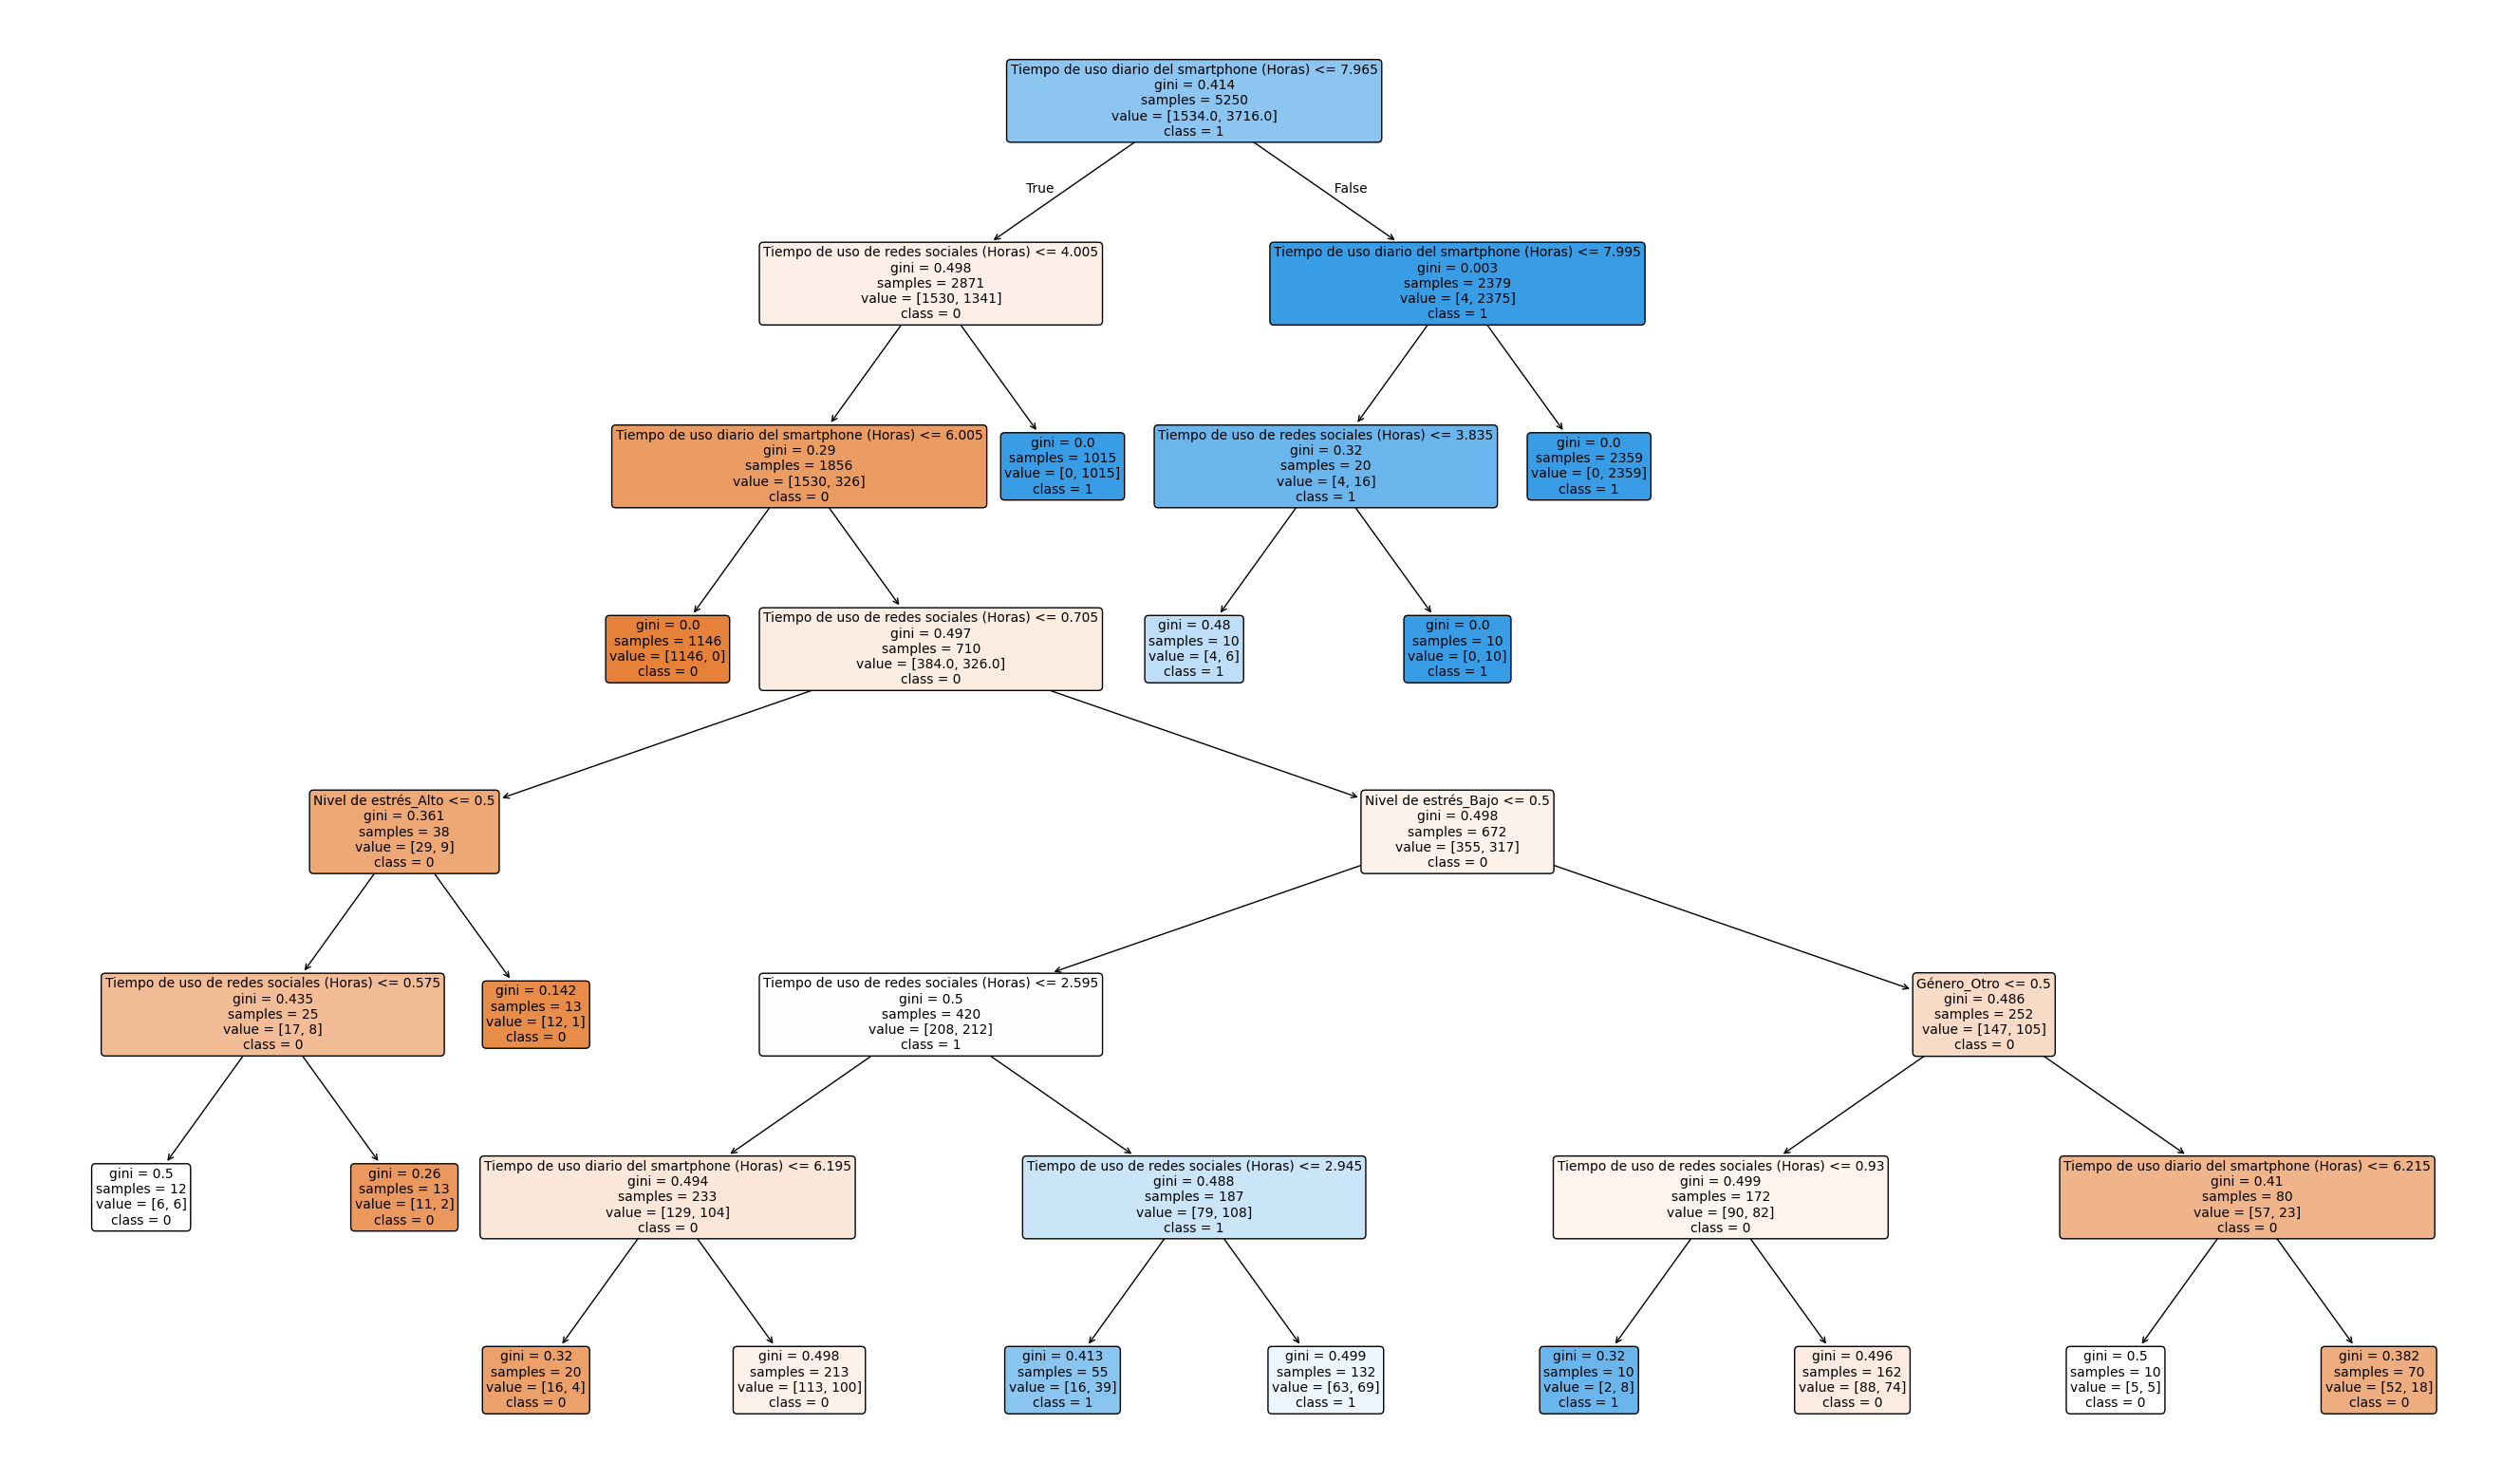

In [ ]:
modelo_arbol = grid_arbol.best_estimator_ #entreno el modelo con los mejores parámetros

#Gráfico de arbol de decisión
plt.figure(figsize=(34,20))
plot_tree(
    modelo_arbol,
    feature_names=x_train.columns,
    class_names=["0","1"],  # ajusta según tus clases
    filled=True,
    rounded=True,
    fontsize=10)
plt.savefig("arbol_decision.pdf", bbox_inches="tight")
plt.show()


In [ ]:
#Predicción con datos de prueba
y_pred_arbol = modelo_arbol.predict(x_test)

Con el fin de evaluar el modelo de clasificación generado se genero la matriz de confusión y se calcularon como metricas de evaluación el accuracy, recall, precision y f1-score.

In [ ]:
cm_arbol = confusion_matrix(y_test, y_pred_arbol)
cm_arbol = pd.DataFrame(cm_arbol,
                            index=["Real 0","Real 1"],
                            columns=["Predicho 0","Predicho 1"])
cm_arbol

,Predicho 0,Predicho 1
Real 0,612,46
Real 1,91,1501


In [ ]:
#Métricas de evaluación
accuracy_arbol = accuracy_score(y_test,y_pred_arbol)
precision_arbol = precision_score(y_test,y_pred_arbol)
recall_arbol = recall_score(y_test,y_pred_arbol)
f1_arbol = f1_score(y_test,y_pred_arbol)

In [ ]:
print(classification_report(y_test,y_pred_arbol))

              precision    recall  f1-score   support

           0       0.87      0.93      0.90       658
           1       0.97      0.94      0.96      1592

    accuracy                           0.94      2250
   macro avg       0.92      0.94      0.93      2250
weighted avg       0.94      0.94      0.94      2250



Se observa que el accuracy del modelo arbol de decisión (0.94)  es mayor y mejor que el modelo logistico (0.89).
Así mismo, presenta mayores métricas en precision, sensibilidad y f1_score. Permitiendo evidenciar una mejor capacidad para predecir los 0 y 1 de foma correcta con relación al modelo logistico. De hecho, en el modelo del arbol se obtuvieron 612 casos verdaderamente positivos (0) y 1501 casos verdaderamente negativos (0). Mientra que en el logistico se encontraron 489 verdaderamente positivos y 1509 verdaderamente negativos. Por lo cual, el modelo del árbol ha resultado ser más preciso y sensible.

In [ ]:
#Importancia de la variable
importancias_arbol= pd.DataFrame({
    "Variable": x_train.columns,
    "Importancia": modelo_arbol.feature_importances_})

importancias_arbol= importancias_arbol.sort_values(
    by="Importancia",
    ascending=False)

importancias_arbol

,Variable,Importancia
0,Tiempo de uso diario del smartphone (Horas),0.502637
1,Tiempo de uso de redes sociales (Horas),0.493358
4,Género_Otro,0.002127
6,Nivel de estrés_Bajo,0.001329
5,Nivel de estrés_Alto,0.000550
2,Género_Hombre,0.000000
3,Género_Mujer,0.000000
7,Nivel de estrés_Medio,0.000000


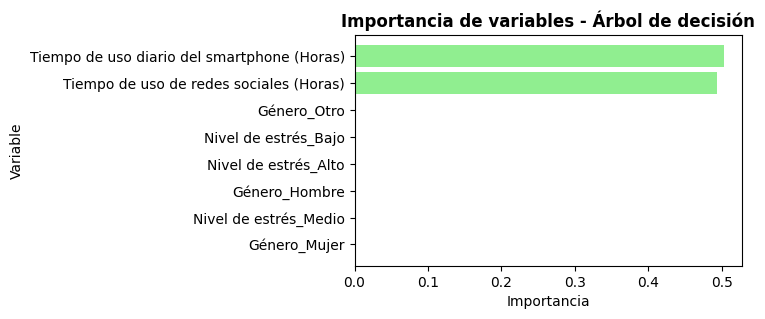

In [ ]:
importancias_arbol= importancias_arbol.sort_values(
    by="Importancia",
    ascending=True)
plt.figure(figsize=(5,3))
plt.barh( importancias_arbol["Variable"], importancias_arbol["Importancia"],color="lightgreen")

plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.title("Importancia de variables - Árbol de decisión",fontweight="bold")

plt.show()

Se observa que para el árbol de decisión las variables más importantes son el Tiempo de uso diario del smartphone y el tiempo de uso de redes sociales (Horas). Las variables categoricas relacionadas al género y nivel de estrés no son representadas como variables de gran importancia en el modelo.

In [ ]:
#Reglas
print(export_text(
    modelo_arbol,
    feature_names=list(x_train.columns)))

|--- Tiempo de uso diario del smartphone (Horas) <= 7.96
|   |--- Tiempo de uso de redes sociales (Horas) <= 4.01
|   |   |--- Tiempo de uso diario del smartphone (Horas) <= 6.01
|   |   |   |--- class: 0
|   |   |--- Tiempo de uso diario del smartphone (Horas) >  6.01
|   |   |   |--- Tiempo de uso de redes sociales (Horas) <= 0.70
|   |   |   |   |--- Nivel de estrés_Alto <= 0.50
|   |   |   |   |   |--- Tiempo de uso de redes sociales (Horas) <= 0.57
|   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |--- Tiempo de uso de redes sociales (Horas) >  0.57
|   |   |   |   |   |   |--- class: 0
|   |   |   |   |--- Nivel de estrés_Alto >  0.50
|   |   |   |   |   |--- class: 0
|   |   |   |--- Tiempo de uso de redes sociales (Horas) >  0.70
|   |   |   |   |--- Nivel de estrés_Bajo <= 0.50
|   |   |   |   |   |--- Tiempo de uso de redes sociales (Horas) <= 2.59
|   |   |   |   |   |   |--- Tiempo de uso diario del smartphone (Horas) <= 6.19
|   |   |   |   |   |   |   |--- class: 

Se aplicó también la curva de ROC y AUC para evaluar el modelo. En esta se determinar que cuanto más cerca esté la curva de la esquina superior izquierda, mejor.

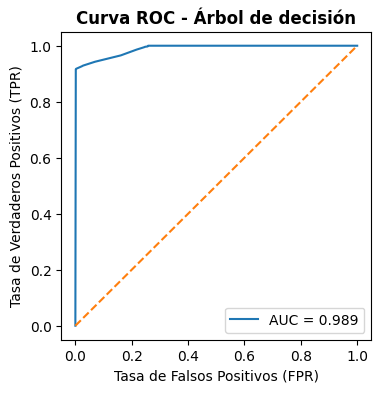

In [ ]:
#Curva ROC y AUC
y_prob_arbol = modelo_arbol.predict_proba(x_test)[:,1]
fpr_arbol,tpr_arbol,_ =roc_curve(y_test,y_prob_arbol)
auc_arbol=roc_auc_score(y_test,y_prob_arbol)

plt.figure(figsize=(4,4))
plt.plot(
    fpr_arbol,
    tpr_arbol,
    label=f"AUC = {auc_arbol:.3f}")
plt.plot([0,1],[0,1],"--")
plt.xlabel("Tasa de Falsos Positivos (FPR)")
plt.ylabel("Tasa de Verdaderos Positivos (TPR)")
plt.title("Curva ROC - Árbol de decisión",fontweight="bold")
plt.legend()
plt.show()

Se observa que la curva ROC se aproxima a la esquina superior izquierda del gráfico, lo que indica una baja tasa de falsos positivos (FPR cercana a 0) y una alta tasa de verdaderos positivos (TPR cercana a 1). Esto evidencia una buena capacidad del modelo para discriminar entre las clases.

Por último se elaboró la curva de Precision-Recall del modelo.

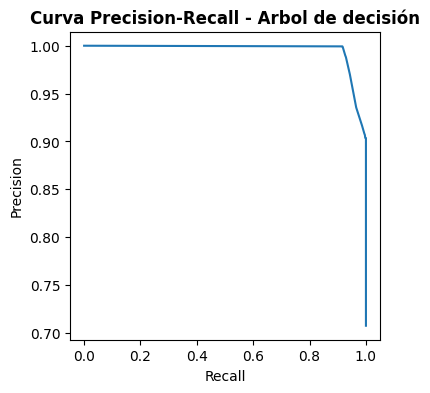

In [ ]:
#Curva precision-recall modelo árbol de decisión
precision_pr_arbol, recall_pr_arbol, _ = precision_recall_curve(y_test, y_prob_arbol)
plt.figure(figsize=(4,4))
plt.plot(recall_pr_arbol, precision_pr_arbol)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Curva Precision-Recall - Arbol de decisión",fontweight="bold")
plt.show()



### ***6.3 Random Forest:***

Random forest es un algoritmo de aprendizaje automatico supervisado usado en clasificación y regresión. Funciona con la contrucción de múltiple arboles de decisión que luego son combinados.

In [ ]:
param_grid_rf = {
    "n_estimators":[100,200], #Número de arboles que tendra el bosque
    "max_depth":[5,10], #Número de niveles
    "min_samples_leaf":[10,20,50]} #Número mínimo de observaciones por hoja


In [ ]:
grid_rforest = GridSearchCV(estimator=RandomForestClassifier(random_state=0), #Modelo random forest
                            param_grid=param_grid_rf, #Parametros a probar
                            cv=cv, #Parametros de la validación cruzada para probar la combinación de parametros
                            scoring="f1", #Métrica para seleccionar el mejor modelo
                            n_jobs=-1) #Utilizar todos los nucleos del procesador
grid_rforest.fit(x_train,y_train) #Se utiliza los datos originales (no escalados) porque rf se basa en puntos de corte más no en distancias
grid_rforest.best_params_ #Obtención de mejores parámetros

{'max_depth': 10, 'min_samples_leaf': 10, 'n_estimators': 200}

In [ ]:
modelo_rforest = grid_rforest.best_estimator_ #Entreo el modelo con los mejores parametros

y_pred_rforest=modelo_rforest.predict(x_test) #predicción con datos de prueba

Con el fin de evaluar el modelo de clasificación generado se genero la matriz de confusión y se calcularon como metricas de evaluación el accuracy, recall, precision y f1-score.

In [ ]:
#Matriz de confusion
cm_rforest = confusion_matrix(y_test,y_pred_rforest)
cm_rforest = pd.DataFrame(cm_rforest,
                            index=["Real 0","Real 1"],
                            columns=["Predicho 0","Predicho 1"])
cm_rforest

,Predicho 0,Predicho 1
Real 0,572,86
Real 1,69,1523


In [ ]:
accuracy_rforest = accuracy_score(y_test,y_pred_rforest)
precision_rforest = precision_score(y_test,y_pred_rforest)
recall_rforest = recall_score(y_test,y_pred_rforest)
f1_rforest = f1_score(y_test,y_pred_rforest)

In [ ]:
print(classification_report(y_test,y_pred_rforest))

              precision    recall  f1-score   support

           0       0.89      0.87      0.88       658
           1       0.95      0.96      0.95      1592

    accuracy                           0.93      2250
   macro avg       0.92      0.91      0.92      2250
weighted avg       0.93      0.93      0.93      2250



A comparación con el modelo arbol de decision, el random forest disminuye el promedio de recall (sensibilidad) por lo cual se le escapa algunos casos con indice de adiccion realmente de 1.

Por esta razón, el f1-score de random forest es ligeramente menor que el del modelo del arbol.

Se analizaron así mismo las importancia de cada variable en este modelo.

In [ ]:
importancias_rforest= pd.DataFrame({"Variable:": x.columns,
                                 "Importancia:":modelo_rforest.feature_importances_}).sort_values(by="Importancia:",ascending=False)

importancias_rforest

,Variable:,Importancia:
0,Tiempo de uso diario del smartphone (Horas),0.591918
1,Tiempo de uso de redes sociales (Horas),0.401779
5,Nivel de estrés_Alto,0.001356
6,Nivel de estrés_Bajo,0.001262
4,Género_Otro,0.001069
3,Género_Mujer,0.000996
7,Nivel de estrés_Medio,0.000841
2,Género_Hombre,0.000779


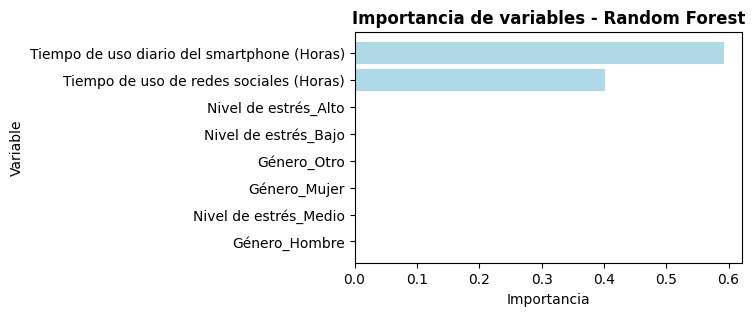

In [ ]:
importancias_rforest= importancias_rforest.sort_values(by="Importancia:",ascending=True)
plt.figure(figsize=(5,3))
plt.barh( importancias_rforest["Variable:"], importancias_rforest["Importancia:"],color="lightblue")


plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.title("Importancia de variables - Random Forest",fontweight="bold")

plt.show()

Se observa que para el árbol de decisión las variables más importantes son el Tiempo de uso diario del smartphone y el tiempo de uso de redes sociales (Horas). Las variables categoricas relacionadas al género y nivel de estrés no son representadas como variables de gran importancia en el modelo.

Se aplicó también la curva de ROC y AUC para evaluar el modelo. En esta se determinar que cuanto más cerca esté la curva de la esquina superior izquierda, mejor.

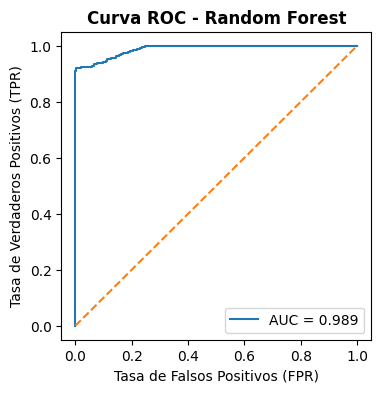

In [ ]:
#Curva ROC y AUC
y_prob_rforest = modelo_rforest.predict_proba(x_test)[:,1]
fpr_rforest,tpr_rforest,_ = roc_curve(y_test,y_prob_rforest)
auc_rforest = roc_auc_score(y_test,y_prob_rforest)

plt.figure(figsize=(4,4))
plt.plot(
    fpr_rforest,
    tpr_rforest,
    label=f"AUC = {auc_rforest:.3f}")
plt.plot([0,1],[0,1],"--")
plt.xlabel("Tasa de Falsos Positivos (FPR)")
plt.ylabel("Tasa de Verdaderos Positivos (TPR)")
plt.title("Curva ROC - Random Forest",fontweight="bold")
plt.legend()
plt.show()

Se observa que AUC del modelo de Random Forest es igual al del modelo Arbol de decisión. Se observa ligeros cambios en la curva ROC donde parece menos genralizada que la curva ROC del arbol de decisión.

Por último se elaboró la curva de precision-Recall del modelo.

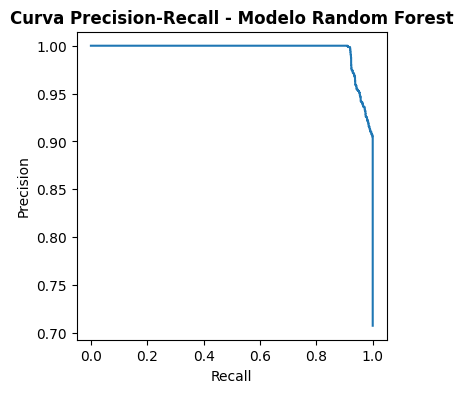

In [ ]:
#Curva precision-recall modelo Random Forest
precision_pr_rforest, recall_pr_rforest, _ = precision_recall_curve(y_test, y_prob_rforest)
plt.figure(figsize=(4,4))
plt.plot(recall_pr_rforest, precision_pr_rforest)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Curva Precision-Recall - Modelo Random Forest",fontweight="bold")
plt.show()

### ***6.4 KNN:***

El modelo KNN de vecinos más cercanos es un algoritmo clasificador de aprendizaje supervisado que utiliza la proximidad para hacer clasificaciones o predicciones sobre la agrupación de un punto de datos individual.  Funciona bajo la suposición de que se pueden encontrar puntos similares cerca unos de otros.

In [ ]:
param_grid_knn={
    "n_neighbors":[3,5,7,9,11],#Número de vecinos más cercanos para decidir la clase
    "weights":["uniform","distance"]} #uniform donde los vecinos pesan igual, distance donde los vecinos más cercanos pesan más

In [ ]:
grid_knn =GridSearchCV(
    estimator=KNeighborsClassifier(), #Modelo de clasificaación mediante vecino más cercano
    param_grid=param_grid_knn, #Parametros a probar
    cv=cv, #Parametros de la combinación cruzada
    scoring="f1", # Métrica para seleccionar el mejor modelo
    n_jobs=-1) #Utilizar todos los núcleos del procesador.

grid_knn.fit(x_train_scaled,y_train) #Genero combinaciones de parámetros y aplico validación cruzada con cada uno de ellos
grid_knn.best_params_ #Obtención de mejores parametros


{'n_neighbors': 7, 'weights': 'distance'}

In [ ]:
modelo_knn = grid_knn.best_estimator_ #Entreno el modelo con los mejores parámetros

#Predicción con datos de prueba
y_pred_knn = modelo_knn.predict(x_test_scaled)

Con el fin de evaluar el modelo de clasificación generado se genero la matriz de confusión y se calcularon como metricas de evaluación el accuracy, recall, precision y f1-score.

In [ ]:
#Matriz de confusion
cm_knn= confusion_matrix(y_test,y_pred_knn)
cm_knn = pd.DataFrame(cm_knn,
                            index=["Real 0","Real 1"],
                            columns=["Predicho 0","Predicho 1"])
cm_knn

,Predicho 0,Predicho 1
Real 0,572,86
Real 1,89,1503


In [ ]:
#Métricas
accuracy_knn = accuracy_score(y_test,y_pred_knn)
precision_knn = precision_score(y_test,y_pred_knn)
recall_knn = recall_score(y_test,y_pred_knn)
f1_knn = f1_score(y_test,y_pred_knn)

In [ ]:
print(classification_report(y_test,y_pred_knn))

              precision    recall  f1-score   support

           0       0.87      0.87      0.87       658
           1       0.95      0.94      0.94      1592

    accuracy                           0.92      2250
   macro avg       0.91      0.91      0.91      2250
weighted avg       0.92      0.92      0.92      2250



Al comparar con el modelo de árbol de decisión (el cual ha sido hasta el momento el mejor modelo) se observa que el modelo de knn presencta un accuracy (0.92) precision (0.91) y recall (0.91) menores que el del arbol.  
Se observa una disminución en el número de casos verdaderos negativos mientras que los verdaderos positivos de knn (1503) es muy similar al del arbol (1501). De manera que en parte teniendo en cuenta el desbalance de los casos 0 y 1, el modelo knn tiene una menor capacidad de predicción de los casos reales 0 que los de 1.

Se desarrollo así mismo la gráfica de la importancia de las variables para el modelo.

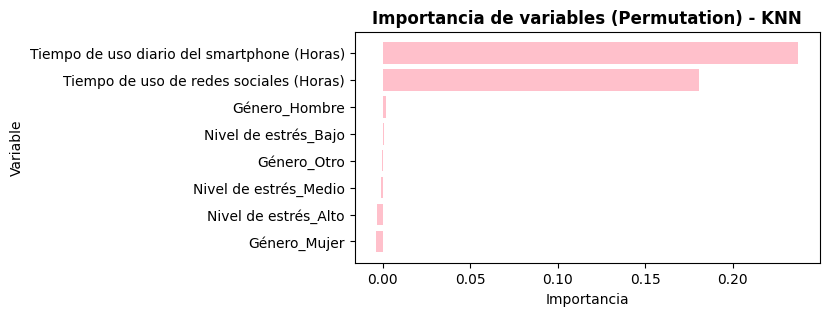

In [ ]:
result = permutation_importance(
    modelo_knn,
    x_test_scaled,
    y_test,
    n_repeats=10,
    random_state=0)

df_knn = pd.DataFrame({
    "variable": x_test.columns,
    "importancia": result.importances_mean
}).sort_values("importancia", ascending=True)

plt.figure(figsize=(6,3))
plt.barh(df_knn["variable"], df_knn["importancia"], color="pink")
plt.title("Importancia de variables (Permutation) - KNN", fontweight="bold")
plt.ylabel("Variable")
plt.xlabel("Importancia")
plt.show()


Se aplicó también la curva de ROC y AUC para evaluar el modelo. En esta se determinar que cuanto más cerca esté la curva de la esquina superior izquierda, mejor.

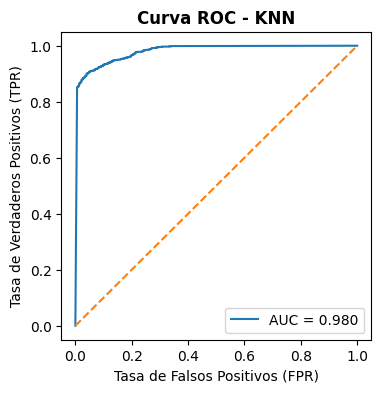

In [ ]:
#Curva ROC y AUC
y_prob_knn = modelo_knn.predict_proba(x_test_scaled)[:,1]
fpr_knn,tpr_knn,_ = roc_curve(y_test,y_prob_knn)
auc_knn = roc_auc_score(y_test,y_prob_knn)


plt.figure(figsize=(4,4))
plt.plot(
    fpr_knn,
    tpr_knn,
    label=f"AUC = {auc_knn:.3f}")
plt.plot([0,1],[0,1],"--")
plt.xlabel("Tasa de Falsos Positivos (FPR)")
plt.ylabel("Tasa de Verdaderos Positivos (TPR)")
plt.title("Curva ROC - KNN",fontweight="bold")
plt.legend()
plt.show()


Se observa un a disminución en la curva ROC y así mismo en el AUC (0.98) frente al modelo del arbol (AUC 0.989).

Por último se elaboró la curva de Precision-Recall del modelo.

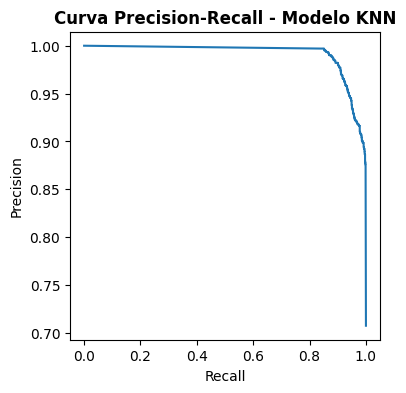

In [ ]:
#Curva precision-recall modelo KNN
precision_pr_knn, recall_pr_knn, _ = precision_recall_curve(y_test, y_prob_knn)
plt.figure(figsize=(4,4))
plt.plot(recall_pr_knn, precision_pr_knn)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Curva Precision-Recall - Modelo KNN",fontweight="bold")
plt.show()


## **Paso 7: Evaluación de modelos y selección del mejor modelo:**

### ***7.1 Comparación de Matrices de confusión:***

In [ ]:
cm_logistico

,Predicho 0,Predicho 1
Real 0,489,169
Real 1,83,1509


In [ ]:
cm_arbol

,Predicho 0,Predicho 1
Real 0,612,46
Real 1,91,1501


In [ ]:
cm_rforest

,Predicho 0,Predicho 1
Real 0,572,86
Real 1,69,1523


In [ ]:
cm_knn

,Predicho 0,Predicho 1
Real 0,572,86
Real 1,89,1503


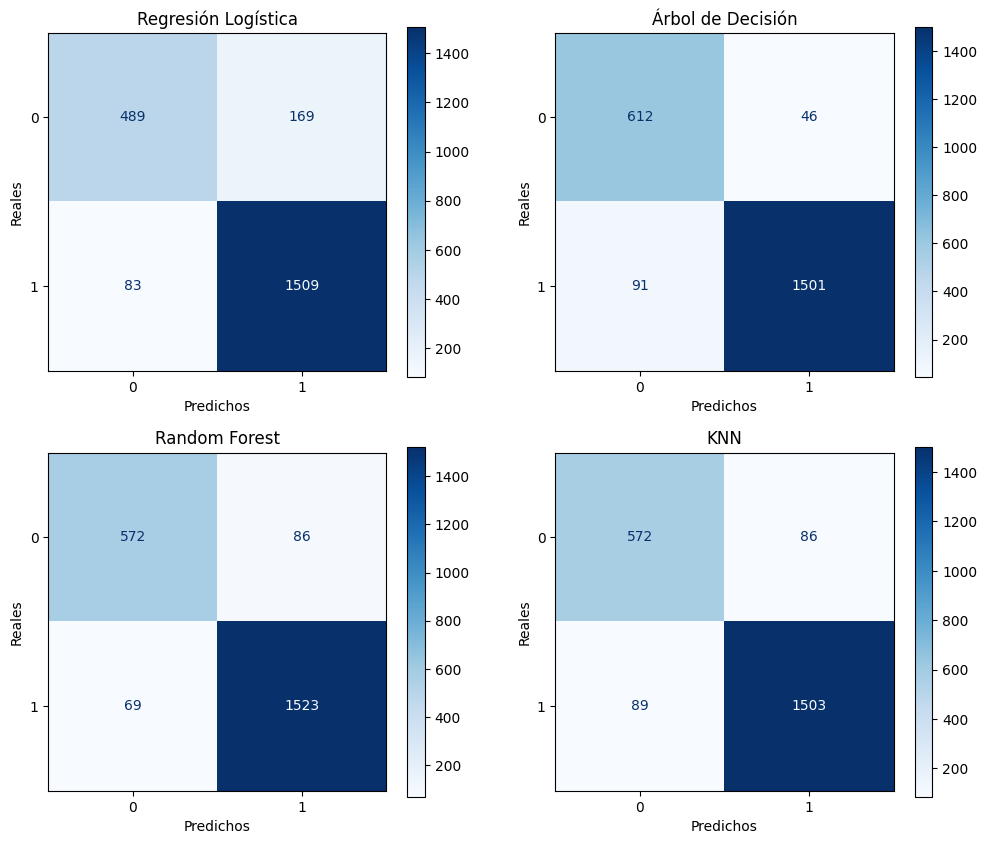

In [ ]:
#Gráficas
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_logistico, ax=axes[0, 0], cmap="Blues")
axes[0, 0].set_title("Regresión Logística")
axes[0,0].set_xlabel("Predichos")
axes[0,0].set_ylabel("Reales")

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_arbol, ax=axes[0, 1], cmap="Blues")
axes[0, 1].set_title("Árbol de Decisión")
axes[0,1].set_xlabel("Predichos")
axes[0,1].set_ylabel("Reales")

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_rforest, ax=axes[1, 0], cmap="Blues")
axes[1, 0].set_title("Random Forest")
axes[1,0].set_xlabel("Predichos")
axes[1,0].set_ylabel("Reales")

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_knn, ax=axes[1, 1], cmap="Blues")
axes[1, 1].set_title("KNN")
axes[1,1].set_xlabel("Predichos")
axes[1,1].set_ylabel("Reales")
plt.show()

Al realizar el comparativo de las matrices de confusion de cada modelo, se evidencia que el modelo arbol presenta una mayor predicción de los casos verdaderamente negativos (es decir, con indice de adicción 0 - Leve), los cuales son los casos más escasos en la base de datos. Sin embargo, teniendo en cuenta que la mayoria de los casos son positivos (indice de adicción 1 moderado/severo), el modelo del arbol presenta una alta tasa  aún asi para determinarlos.

### ***7.2 Comparación de métricas Accuracy y bajo weighted average en Precision, Recall y F1-score:***

Se decide realizar la siguiente tabla comparativa que resume cada una de las métricas de evaluación de los modelos construidos.

In [ ]:
def metricas_weighted(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)

    precision_w, recall_w, f1_w, _ = precision_recall_fscore_support(
        y_true, y_pred, average="weighted"    )

    return acc, precision_w, recall_w, f1_w


In [ ]:
acc_log, prec_log, rec_log, f1_log = metricas_weighted(y_test, y_pred_logistico)
acc_tree, prec_tree, rec_tree, f1_tree = metricas_weighted(y_test, y_pred_arbol)
acc_rf, prec_rf, rec_rf, f1_rf = metricas_weighted(y_test, y_pred_rforest)
acc_knn, prec_knn, rec_knn, f1_knn = metricas_weighted(y_test, y_pred_knn)

In [ ]:
comparacion = pd.DataFrame({
    "Modelo": ["Logístico","Árbol","Random Forest","KNN"],
    "Accuracy": [acc_log, acc_tree, acc_rf, acc_knn],
    "Precision (weighted)": [prec_log, prec_tree, prec_rf, prec_knn],
    "Recall (weighted)": [rec_log, rec_tree, rec_rf, rec_knn],
    "F1 (weighted)": [f1_log, f1_tree, f1_rf, f1_knn]})
comparacion.round(2)

,Modelo,Accuracy,Precision (weighted),Recall (weighted),F1 (weighted)
0,Logístico,0.89,0.89,0.89,0.89
1,Árbol,0.94,0.94,0.94,0.94
2,Random Forest,0.93,0.93,0.93,0.93
3,KNN,0.92,0.92,0.92,0.92


Dado que el dataset se encuentra desbalanceado (más casos 1 que 0) se utilizó como principal métrica de evaluación el F1-score, la cual ofrece un balance entre precisión (evitar falsos negativos) y recall (evitar falsos positivos).

Razón por la cual el modelo más óptimo es el modelo del arbol de decisión.

### ***7.3 Comparación curvas ROC y AUC:***

Así mismo, se realizó una grafica comparativa que recogiera las curvas ROC y el AUC de cada modelo.

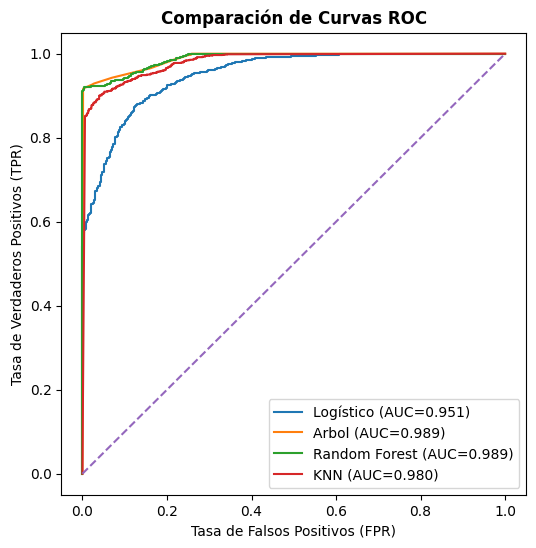

In [ ]:
#Comparación de curva de AUC y ROC
plt.figure(figsize=(6,6))

plt.plot(fpr_logistico,tpr_logistico,label=f"Logístico (AUC={auc_logistico:.3f})")
plt.plot(fpr_arbol,tpr_arbol,label=f"Arbol (AUC={auc_arbol:.3f})")
plt.plot(fpr_rforest,tpr_rforest,label=f"Random Forest (AUC={auc_rforest:.3f})")
plt.plot(fpr_knn,tpr_knn,label=f"KNN (AUC={auc_knn:.3f})")


plt.plot([0,1],[0,1],"--")

plt.xlabel("Tasa de Falsos Positivos (FPR)")
plt.ylabel("Tasa de Verdaderos Positivos (TPR)")
plt.title("Comparación de Curvas ROC",fontweight="bold")
plt.legend()
plt.show()

Inicialmente, se identifica mediante la gráfica que las curvas ROC con mejor sensibilidad para detectar correctamente los casos verdaderos positivos (índice de adicción = 1 moderado/severo) y baja tasa de falsos positivos es entre el modelo Árbol de decisión y Random Forest. Ambos modelos presentan la misma área bajo la curva (AUC), sin embargo, como observábamos anteriormente, el modelo de árbol de decisión presentó mejores métricas en precisión, Recall, F1-Score teniendo en cuenta los datos desbalanceados.

Con base en los resultados de las métricas de evaluación, se determinó que el mejor modelo clasificatorio es el del árbol de decisión.

### ***7.4 Comparación curvas Precision-Recall***

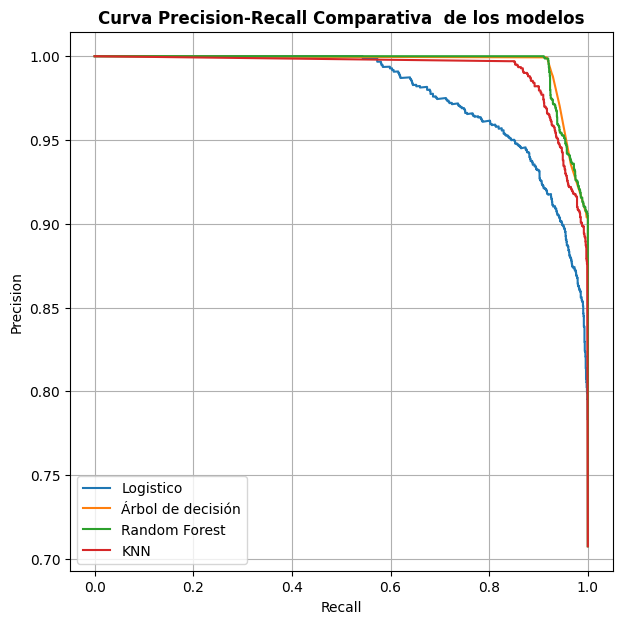

In [ ]:
#Curva precision-recall comparativa
plt.figure(figsize=(7,7))
plt.plot(recall_pr_logistico, precision_pr_logistico, label="Logistico")
plt.plot(recall_pr_arbol, precision_pr_arbol, label="Árbol de decisión")
plt.plot(recall_pr_rforest, precision_pr_rforest, label="Random Forest")
plt.plot(recall_pr_knn, precision_pr_knn, label="KNN")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Curva Precision-Recall Comparativa  de los modelos", fontweight="bold")
plt.legend()
plt.grid(True)
plt.show()



Para cada uno de los modelos construidos, se elaboró la curva de Precision – Recall . Al realizar la comparación, es posible identificar que los modelos Arvol de decisión y Random Forest presentan curvas muy similares. Para estos dos modelos se observa que presentan una mayor precisión (pocos casos falsos positivos – índice de adicción 1 moderado/severo) que sensibilidad (Recall – detección de los casos positivos reales índice de adicción 1 moderado/severo).
A comparación, el modelo logístico muestra una baja precisión (mayor tasa de falsos positivos) y bajo Recall (detecta una baja tasa de casos positivos reales). Mientras que el modelo KNN presenta una mejor precisión y Recall que el logístico pero menor que el de los modelos Random Forest y Ábol de decisión.


### **Conclusiones:**

*	Se desarrollaron y evaluaron diferentes modelos de clasificación, incluyendo regresión logística, árbol de decisión, Random Forest y KNN, con el objetivo de predecir el nivel de adicción de los individuos a partir de las variables disponibles.

*	El modelo de árbol de decisión fue seleccionado como modelo final debido a su desempeño superior en las métricas evaluadas, particularmente en términos de F1-score, precision, recall y accuracy. Además, presentó resultados comparables a los de Random Forest en la curva ROC y en la calibración de probabilidades.

*	Es posible adelantar una mejora del modelo considerando únicamente las dos variables de más importancia (Tiempo de uso del smartphone y el tiempo de uso en redes sociales). Y así mismo, considerar la construcción de nuevos modelos a partir de la recolección y  construcción de un nuevo data set que involucre nuevas variables para identificar su importancia en la clasificación del nivel de adicción.


### **Referencias Bibliográficas:**

* Label AI. (2022). *What is accuracy, precision,
recall and F1 score?*.  Recuperado de: https://labelf.ai/blog/what-is-accuracy-precision-recall-and-f1-score

* IBM. (s. f.).*¿Qué es Random Forest?* . Recuperado de: https://www.ibm.com/mx-es/think/topics/random-forest

* IBM. (s. f.). *¿Qué son los árboles de decisión?* . Recuperado de:  https://www.ibm.com/es-es/think/topics/decision-trees


### **Tiempos de entrenamiento:**

In [ ]:
#Modelo logistico
inicio = time.time()

grid_logistico.fit(x_train_scaled, y_train)

fin = time.time()

print(fin - inicio)

0.5108270645141602


In [ ]:
# Modelo Arbol de decisión
inicio = time.time()

grid_arbol.fit(x_train, y_train)

fin = time.time()

print(fin - inicio)

1.097320556640625


In [ ]:
#Modelo Random Forest
inicio = time.time()

grid_rforest.fit(x_train, y_train)

fin = time.time()

print(fin - inicio)

27.06948471069336


In [ ]:
# Modelo KNN
inicio = time.time()

grid_knn.fit(x_train_scaled, y_train)

fin = time.time()

print(fin - inicio)

0.9766111373901367
